# Lab-Scale CSTR pH Neutralisation — Controller Comparison

This notebook models a lab-scale, well-mixed CSTR neutralisation process and compares four
controller design philosophies on it:

1. **Conventional PID** — a single fixed tuning (Ziegler–Nichols, open-loop reaction-curve
   method) based on the *averaged* process dynamics across the whole pH range.
2. **IMC-based PI** — a single fixed tuning derived from Internal Model Control (lambda
   tuning), also based on the averaged process dynamics.
3. **IMC-scheduled PID** — the IMC-PI/PID tunings computed separately for the acidic,
   neutral and alkaline regions, interpolated continuously by measured pH.
4. **Pure gain-scheduled PID** — a classical gain-scheduling controller: the proportional
   gain is scheduled *continuously* and *directly* from the process's own nonlinear
   steady-state gain curve (the titration curve), so that the loop gain $K_c \cdot K_p(\mathrm{pH})$
   stays approximately constant across the operating range. $T_i$ and $T_d$ are held fixed
   at a Ziegler–Nichols reference tuning. This is independent of the IMC/lambda-tuning
   framework and is the "textbook" gain-scheduling response to a compounding process
   nonlinearity (Kalafatis et al., 1992; Shinskey; Leith & Leithead, 2000).

**Structure:** all shared machinery (process model, step-test routine, performance metrics,
the piecewise-linear gain scheduler, and the closed-loop simulator) is defined once in the
*Shared setup* section below and reused throughout, instead of being redefined in every
section.


## Shared setup

Process constants, the steady-state/dynamic CSTR model, and every helper function used
later in the notebook (step-test runner, performance metrics, the piecewise-linear gain
scheduler, and the closed-loop simulator) are defined **once**, here.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

# ============================================================
# PROCESS CONSTANTS (lab-scale CSTR)
# ============================================================
Qa = 0.005 * 1000   # mL/s, acid volumetric flow
Ca = 0.01            # mol/L, acid concentration
Cb = 0.01            # mol/L, base concentration
Kw = 1e-14           # water equilibrium constant
V  = 10 * 1000       # mL, reactor volume

print("--- System Inputs ---")
print(f"Acid Volumetric Flow (Qa): {Qa} mL/s")
print(f"Acid Concentration (Ca): {Ca} mol/L")
print(f"Base Concentration (Cb): {Cb} mol/L")
print(f"Water Equilibrium Constant (Kw): {Kw}")
print(f"Reactor Volume (V): {V} mL")
print("---------------------")

--- System Inputs ---
Acid Volumetric Flow (Qa): 5.0 mL/s
Acid Concentration (Ca): 0.01 mol/L
Base Concentration (Cb): 0.01 mol/L
Water Equilibrium Constant (Kw): 1e-14
Reactor Volume (V): 10000 mL
---------------------


In [2]:
# ============================================================
# CHARGE-BALANCE <-> pH CONVERSIONS
# ============================================================
# x = [H+] - [OH-] is the conserved reaction-invariant charge balance used as the
# state variable throughout (Kalafatis et al., 1992; McAvoy et al.).

def x_to_pH(x):
    """Convert charge-balance state x to pH (vectorised)."""
    H = (x + np.sqrt(x**2 + 4 * Kw)) / 2
    return -np.log10(H)

def pH_to_x(pH):
    """Convert a target pH to the corresponding charge-balance value x."""
    H = 10.0 ** (-pH)
    return H - Kw / H

def residual_Qb(Qb, Qa_val, Ca_val, Cb_val, x_target):
    """Steady-state charge balance residual, used with fsolve to find the base
    flow Qb that holds the reactor at a target x (equivalently, a target pH)."""
    return (Qa_val * Ca_val - Qb * Cb_val) / (Qa_val + Qb) - x_target

def solve_Qb_for_pH(pH_target, guess, Ca_val=None):
    """Steady-state base flow Qb0 required to hold the reactor at pH_target."""
    Ca_val = Ca if Ca_val is None else Ca_val
    x_target = pH_to_x(pH_target)
    return fsolve(residual_Qb, guess, args=(Qa, Ca_val, Cb, x_target))[0]

def default_F_max(pH_ref=9.0):
    """A generous upper bound on the base flow actuator, computed from the physics
    (the flow that would drive the reactor to pH_ref) rather than a magic number."""
    x_ref = pH_to_x(pH_ref)
    Qb_ref = fsolve(residual_Qb, 1e-3, args=(Qa, Ca, Cb, x_ref))[0]
    return max(2 * Qb_ref, 0.1)

In [3]:
# ============================================================
# STEP-TEST ROUTINE (process identification)
# ============================================================
# Runs a two-stage step test around a target operating pH: first bring the reactor from
# acid-only to the target pH, then apply a small step in Qb and fit a first-order-plus-
# dead-time (FOPDT) model to the response (Kp, tau, theta) using the 63.2%/28.3% method.

def _time_to_percent_change(pc, initial_val, final_val, time_arr, val_arr, step_t):
    """Time after step_t at which val_arr reaches fraction pc of its total change."""
    total_change = final_val - initial_val
    if abs(total_change) < 1e-6:
        return np.nan

    target = initial_val + pc * total_change
    post = time_arr >= step_t
    t_resp, v_resp = time_arr[post], val_arr[post]
    if len(t_resp) == 0:
        return np.nan

    cross = np.where(v_resp >= target)[0] if total_change > 0 else np.where(v_resp <= target)[0]
    if len(cross) == 0:
        return np.nan

    idx = cross[0]
    if idx == 0:
        return t_resp[idx] - step_t

    t1, v1 = t_resp[idx - 1], v_resp[idx - 1]
    t2, v2 = t_resp[idx], v_resp[idx]
    if v2 == v1:
        return t2 - step_t
    return (t1 + (target - v1) * (t2 - t1) / (v2 - v1)) - step_t


def run_step_test(pH_target, step_pct, Qb0_guess, region_label="",
                   t_step=2000, t_step2=20000, tend=30000, n=600, plot=True):
    """
    Identify FOPDT parameters (Kp, tau, theta) around pH_target.

    pH_target : operating point to identify around
    step_pct  : fractional step applied to Qb0 at t_step2 (e.g. 0.0125 for +1.25%)
    Qb0_guess : initial guess for fsolve when finding Qb0
    """
    Qb0 = solve_Qb_for_pH(pH_target, Qb0_guess)
    Qb_new = (1 + step_pct) * Qb0

    def dxdt(t, x):
        if t < t_step:
            Qb = 0.0
        elif t < t_step2:
            Qb = Qb0
        else:
            Qb = Qb_new
        Fout = Qa + Qb
        dx = (Qa * Ca / V) + (Qb * (-Cb) / V) - (Fout / V) * x[0]
        return [dx]

    t_eval = np.linspace(0, tend, n)
    sol = solve_ivp(dxdt, (0, tend), [Ca], t_eval=t_eval)
    pH = x_to_pH(sol.y[0])

    # Fit FOPDT parameters from the response to the second step
    end_settling = t_step2 + (tend - t_step2) * 0.75
    idx_ss = sol.t >= end_settling
    pH_ss = np.mean(pH[idx_ss]) if np.any(idx_ss) else pH[-1]
    delta_Y = pH_ss - pH_target

    t63 = _time_to_percent_change(0.632, pH_target, pH_ss, sol.t, pH, t_step2)
    t28 = _time_to_percent_change(0.283, pH_target, pH_ss, sol.t, pH, t_step2)

    Kp = delta_Y / (Qb_new - Qb0)
    tau = 1.5 * (t63 - t28)
    theta = abs(t63 - tau)

    if plot:
        fig, ax1 = plt.subplots(figsize=(11, 4.5))
        ax1.plot(sol.t, pH, color='tab:blue', label='pH')
        ax1.axvline(t_step, color='tab:red', ls='--', alpha=0.7, label=f'Base flow on (t={t_step}s)')
        ax1.axvline(t_step2, color='tab:orange', ls='--', alpha=0.7,
                     label=f'Qb step {step_pct*100:+.3f}% (t={t_step2}s)')
        ax1.axhline(pH_target, color='purple', ls=':', alpha=0.7, label=f'Target pH = {pH_target}')
        ax1.set_xlabel("Time (s)"); ax1.set_ylabel("pH")
        ax1.grid(alpha=0.3)
        ax1.set_title(f"Step test — {region_label} region" if region_label else "Step test")
        ax1.legend(loc='best', fontsize=9)
        plt.tight_layout(); plt.show()

    print(f"--- {region_label} region (around pH {pH_target}) ---")
    print(f"Qb0 = {Qb0:.5f} mL/s  ->  Qb_new = {Qb_new:.5f} mL/s  ({step_pct*100:+.3f}%)")
    print(f"Process gain Kp = {Kp:.4f} pH/(mL/s)")
    print(f"Time constant tau = {tau:.2f} s")
    print(f"Dead time theta = {theta:.2f} s\n")

    return Kp, tau, theta

In [4]:
# ============================================================
# CLOSED-LOOP PERFORMANCE METRICS
# ============================================================

PH_SETTLING_BAND = 0.05   # settling band in absolute pH units (not a % of SP -- pH is
                           # logarithmic with an arbitrary origin, so a %-of-SP band gives a
                           # tighter criterion for acidic setpoints than neutral ones purely
                           # as an artefact of the setpoint's numeric value)

def calculate_performance_metrics(t_eval, SP_trace, pH_arr):
    """IAE / ISE / ITAE / overshoot / settling time (+/- PH_SETTLING_BAND pH) for every
    distinct, real setpoint change in SP_trace. Segments where the setpoint does not
    change (SP_old == SP_new) are skipped: they are not a setpoint step and would
    otherwise dilute the per-controller group means downstream."""
    dt = t_eval[1] - t_eval[0]
    sp_change_indices = [0] + list(np.where(np.diff(SP_trace) != 0)[0] + 1)

    results = []
    step_num = 0
    for i in range(len(sp_change_indices)):
        start_idx = sp_change_indices[i]
        end_idx = sp_change_indices[i + 1] if (i + 1) < len(sp_change_indices) else len(t_eval)

        SP_old = SP_trace[start_idx - 1] if start_idx > 0 else SP_trace[0]
        SP_new = SP_trace[start_idx]

        if SP_old == SP_new:
            continue

        if end_idx > start_idx:
            t_slice = t_eval[start_idx:end_idx]
            SP_slice = SP_trace[start_idx:end_idx]
            pH_slice = pH_arr[start_idx:end_idx]
        else:
            t_slice = t_eval[start_idx:start_idx + 1]
            SP_slice = SP_trace[start_idx:start_idx + 1]
            pH_slice = pH_arr[start_idx:start_idx + 1]
        if len(t_slice) == 0:
            continue

        error_slice = SP_slice - pH_slice
        iae = np.sum(np.abs(error_slice)) * dt
        ise = np.sum(error_slice**2) * dt
        t_shifted = t_slice - t_slice[0]
        itae = np.sum(t_shifted * np.abs(error_slice)) * dt

        overshoot = 0.0
        if SP_new > SP_old:
            dev = pH_slice - SP_new
            dev = dev[dev > 0]
            if len(dev) > 0:
                overshoot = np.max(dev)
        elif SP_new < SP_old:
            dev = SP_new - pH_slice
            dev = dev[dev > 0]
            if len(dev) > 0:
                overshoot = np.max(dev)

        settling_time = np.inf
        tol = PH_SETTLING_BAND
        upper, lower = SP_new + tol, SP_new - tol
        out_of_band = (pH_slice < lower) | (pH_slice > upper)
        out_idx = np.where(out_of_band)[0]
        if len(out_idx) == 0:
            settling_time = 0.0
        else:
            last = out_idx[-1]
            if last == len(t_slice) - 1:
                settling_time = np.inf
            elif np.all(~out_of_band[last + 1:]):
                settling_time = t_slice[last + 1] - t_slice[0]

        step_num += 1
        results.append({
            'Step': step_num, 'Time': t_slice[0],
            'SP_Transition': f"{SP_old:.2f} -> {SP_new:.2f}",
            'IAE': iae, 'ISE': ise, 'ITAE': itae,
            'Overshoot': overshoot, 'Settling_Time': settling_time,
        })
    return results


def metrics_table(metrics_list):
    """Tidy pandas table of a metrics_list, ready to paste into the report."""
    df = pd.DataFrame(metrics_list)
    if df.empty:
        return df
    df = df.rename(columns={
        'Step': 'Step', 'Time': 'Time (s)', 'SP_Transition': 'SP transition',
        'IAE': 'IAE', 'ISE': 'ISE', 'ITAE': 'ITAE',
        'Overshoot': 'Overshoot (pH)', 'Settling_Time': 'Settling time (s)',
    })
    return df.round(3)


In [5]:
# ============================================================
# PIECEWISE-LINEAR GAIN SCHEDULER
# ============================================================

class PiecewiseLinearGainController:
    """Interpolates a scheduled gain (Kc, Ti or Td) linearly between (PV, gain)
    breakpoints. Used both for the IMC-scheduled controller (few, region-based
    breakpoints) and the pure gain-scheduled controller (many breakpoints tracing
    out a continuous curve)."""

    def __init__(self, breakpoints):
        self.breakpoints = sorted(breakpoints, key=lambda p: p[0])
        if len(self.breakpoints) < 2:
            raise ValueError("At least two breakpoints are required for interpolation.")

    def calculate_gain(self, current_pv):
        bp = self.breakpoints
        if current_pv <= bp[0][0]:
            return bp[0][1]
        if current_pv >= bp[-1][0]:
            return bp[-1][1]
        for (x1, y1), (x2, y2) in zip(bp[:-1], bp[1:]):
            if x1 <= current_pv <= x2:
                if x2 == x1:
                    return y1
                return y1 + (current_pv - x1) * (y2 - y1) / (x2 - x1)


def print_gain_schedule_details(name, breakpoints):
    print(f"--- {name} schedule ({len(breakpoints)} breakpoints) ---")
    bp = sorted(breakpoints, key=lambda p: p[0])
    for i in range(min(len(bp) - 1, 8)):
        x1, y1 = bp[i]; x2, y2 = bp[i + 1]
        if x2 == x1:
            print(f"  pH = {x1:.2f}: constant gain = {y1:.4f}")
            continue
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        print(f"  pH {x1:.2f} to {x2:.2f}: gain = {m:.4f}*pH + {b:.4f}")
    if len(bp) - 1 > 8:
        print(f"  ... ({len(bp) - 1 - 8} more segments)")

In [6]:
# ============================================================
# CLOSED-LOOP SIMULATOR (used by every controller in this notebook)
# ============================================================
# Kc, Ti, Td may each be a constant (fixed-gain controller) or a
# PiecewiseLinearGainController (gain-scheduled on measured pH) -- the same function
# handles the conventional, IMC, IMC-scheduled and pure gain-scheduled controllers.

def run_closed_loop_sim(Kc, Ti, Td=0.0, sp_events=None, dist_events=None,
                         initial_pH=None, theta_dead=None,
                         F_min=0.0, F_max=None, tend=100000, n_points=None,
                         schedule_filter_tau=0.0,
                         title="Closed-Loop pH Control", show_mv=False, plot=True):
    """
    schedule_filter_tau : if > 0, the pH used to *look up* scheduled gains is a
        first-order-filtered version of the measurement (a standard practical fix for
        gain-scheduling on a fast/noisy PV: filter it before indexing the schedule, don't
        let the raw measurement -- and hence the schedule -- chatter). The unfiltered
        measurement is still used for the control error itself.
    """
    if not sp_events:
        raise ValueError("sp_events must be a non-empty list, e.g. [{'time': 0, 'SP': 7.0}]")
    dist_events = dist_events or []
    theta_dead = theta if theta_dead is None else theta_dead
    F_max = default_F_max() if F_max is None else F_max

    # Keep the controller sample time dt well below the fastest dynamics anywhere in the
    # operating range (down to ~18-40 s near equivalence). A coarse dt here doesn't just
    # lose accuracy -- for the more aggressive gain-scheduled controllers it can produce a
    # simulation artifact that looks like instability but is really just under-sampling.
    if n_points is None:
        n_points = max(800, int(tend / 20))

    t_eval = np.linspace(0, tend, n_points)
    n = len(t_eval)
    dt = t_eval[1] - t_eval[0]
    theta_steps = max(1, int(theta_dead / dt))

    def sp_at(t):
        cur = sp_events[0]['SP']
        for ev in sp_events:
            if t >= ev['time']:
                cur = ev['SP']
        return cur

    def ca_at(t):
        cur = Ca
        for ev in dist_events:
            if t >= ev['time']:
                cur = Ca * ev['Ca_factor']
        return cur

    def scheduled(val, pH):
        return val.calculate_gain(pH) if isinstance(val, PiecewiseLinearGainController) else val

    initial_pH = sp_events[0]['SP'] if initial_pH is None else initial_pH
    x0_val = pH_to_x(initial_pH)

    F = np.zeros(n); pH_arr = np.zeros(n); e = np.zeros(n)
    pH_arr[0] = initial_pH
    e[0] = sp_at(0) - pH_arr[0]
    F[0] = solve_Qb_for_pH(initial_pH, guess=0.0)
    x0 = [x0_val]
    MV_buffer = np.full(theta_steps, F[0])

    t_span_start = 0.0
    pH_sched_filt = pH_arr[0]
    for k in range(1, n):
        current_SP = sp_at(t_eval[k])
        if schedule_filter_tau > 0:
            alpha = dt / (schedule_filter_tau + dt)
            pH_sched_filt = pH_sched_filt + alpha * (pH_arr[k - 1] - pH_sched_filt)
            current_pH = pH_sched_filt
        else:
            current_pH = pH_arr[k - 1]
        current_Kc = scheduled(Kc, current_pH)
        current_Ti = scheduled(Ti, current_pH)
        current_Td = scheduled(Td, current_pH)

        e[k] = current_SP - pH_arr[k - 1]
        de_val = e[k] - e[k - 1]
        pv_prev1 = pH_arr[k - 2] if k >= 2 else pH_arr[0]
        pv_prev2 = pH_arr[k - 3] if k >= 3 else pH_arr[0]
        de_val2 = pH_arr[k - 1] - 2 * pv_prev1 + pv_prev2

        ti_term = (dt / current_Ti) * e[k] if current_Ti > 1e-6 else 0.0
        td_term = (current_Td / dt) * de_val2 if dt > 1e-6 else 0.0

        dF = current_Kc * (de_val + ti_term - td_term)
        F[k] = np.clip(F[k - 1] + dF, F_min, F_max)

        Qb_delayed = MV_buffer[-1]
        MV_buffer = np.roll(MV_buffer, 1)
        MV_buffer[0] = F[k]

        current_Ca = ca_at(t_eval[k])

        def dxdt_func(t, x_vec, Qb_in, Ca_val):
            Fout = Qa + Qb_in
            dx = (Qa * Ca_val / V) + (Qb_in * (-Cb) / V) - (Fout / V) * x_vec[0]
            return [dx]

        sol = solve_ivp(dxdt_func, (t_span_start, t_span_start + dt), x0,
                         args=(Qb_delayed, current_Ca), method='RK45')
        x0 = [sol.y[0, -1]]
        t_span_start += dt
        pH_arr[k] = x_to_pH(x0[0])

    SP_trace = np.array([sp_at(t) for t in t_eval])
    metrics_list = calculate_performance_metrics(t_eval, SP_trace, pH_arr)

    if plot:
        fig, ax1 = plt.subplots(figsize=(11, 4.8))
        ax1.plot(t_eval, pH_arr, color='tab:blue', label='pH (PV)')
        ax1.plot(t_eval, SP_trace, color='tab:red', ls='--', label='Setpoint (SP)')
        for dv in dist_events:
            label = dv.get('label', f"Ca x{dv['Ca_factor']}")
            ax1.axvline(dv['time'], color='tab:green', ls=':', alpha=0.7, label=f"{label} (t={dv['time']}s)")
        ax1.set_xlabel("Time (s)"); ax1.set_ylabel("pH")
        ax1.grid(alpha=0.3)
        handles, labels = ax1.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        ax1.legend(uniq.values(), uniq.keys(), loc='lower right', fontsize=8)
        ax1.set_title(title)
        plt.tight_layout(); plt.show()

        if show_mv:
            fig2, ax2 = plt.subplots(figsize=(11, 3.2))
            ax2.step(t_eval, F, color='tab:green', where='post', label='Base flow (MV)')
            ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Flow (mL/s)")
            ax2.grid(alpha=0.3); ax2.legend(loc='best', fontsize=8)
            plt.tight_layout(); plt.show()

    df = metrics_table(metrics_list)
    print(f"--- {title}: performance per setpoint step ---")
    if not df.empty:
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    return {'t': t_eval, 'pH': pH_arr, 'F': F, 'SP': SP_trace,
            'metrics': metrics_list, 'metrics_df': df}

## Titration curve

Steady-state pH as a function of base flow rate `Qb`, for the acid stream defined above.
This is the process's static nonlinearity: it is essentially flat away from the equivalence
point and extremely steep close to it. Everything else in this notebook — the three-region
step tests, the IMC scheduling, and especially the pure gain-scheduled controller in the
final section — exists because of the shape of this curve.


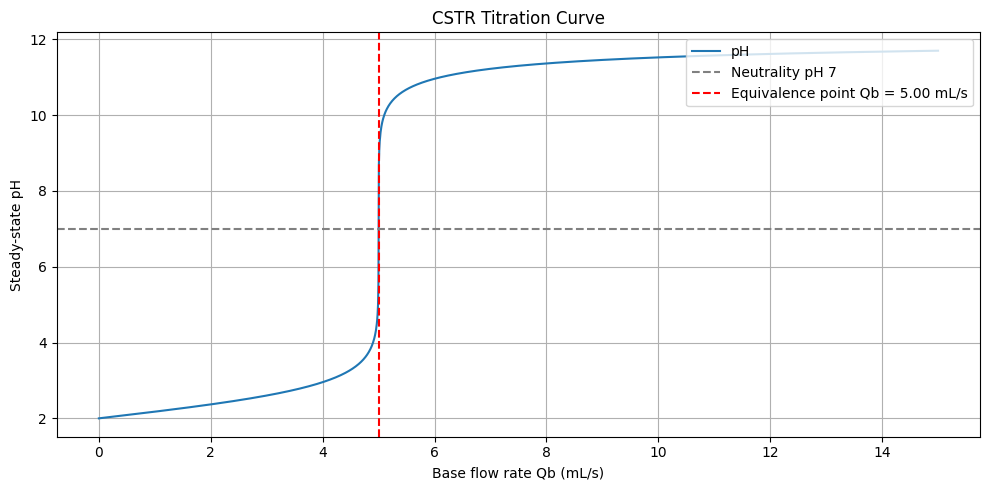

Initial pH (Qb = 0): 2.0000
Equivalence point Qb = 5.00 mL/s


In [7]:
# Sweep base flow and compute the steady-state pH at each point, using the *same*
# steady-state charge-balance formula used everywhere else in this notebook
# (x_ss = (Qa*Ca - Qb*Cb)/(Qa+Qb), i.e. residual_Qb solved at x_target=0's generalisation).
# NOTE: an earlier version of this cell routed the sweep through an intermediate
# Fb = Qb*Cb and used x_ss = (Fa*Ca - Fb*Cb)/(Fa+Fb) with Fa = Qa*Ca -- that is a
# *different, inconsistent* steady-state formula (it effectively used Qa*Ca^2 instead
# of Qa*Ca). It happened to still place the equivalence point in the right spot only
# because Ca = Cb here; the curve's shape away from equivalence was subtly wrong, which
# matters for the pure gain-scheduled controller below, since that controller reads its
# process gain directly off this curve. Fixed here.
titration_Qb = np.linspace(0, 15, 2000)   # mL/s
titration_x = (Qa * Ca - titration_Qb * Cb) / (Qa + titration_Qb)
titration_pH = x_to_pH(titration_x)

Qb_eq = Qa * Ca / Cb   # x_ss = 0

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(titration_Qb, titration_pH, color='tab:blue', label='pH')
ax1.axhline(7, ls='--', color='gray', label='Neutrality pH 7')
ax1.axvline(Qb_eq, ls='--', color='red', label=f'Equivalence point Qb = {Qb_eq:.2f} mL/s')
ax1.set_xlabel("Base flow rate Qb (mL/s)"); ax1.set_ylabel("Steady-state pH")
ax1.grid(True); ax1.legend(loc='upper right')
plt.title("CSTR Titration Curve")
plt.tight_layout(); plt.show()

print(f"Initial pH (Qb = 0): {titration_pH[0]:.4f}")
print(f"Equivalence point Qb = {Qb_eq:.2f} mL/s")

## Step tests around three operating regions

The process is identified as a first-order-plus-dead-time (FOPDT) model — $K_p$, $\tau$,
$\theta$ — around three representative operating points: acidic (pH 4), near-neutral
(pH 6) and alkaline (pH 9). These three (Kp, tau, theta) sets are the basis for every
controller design that follows.


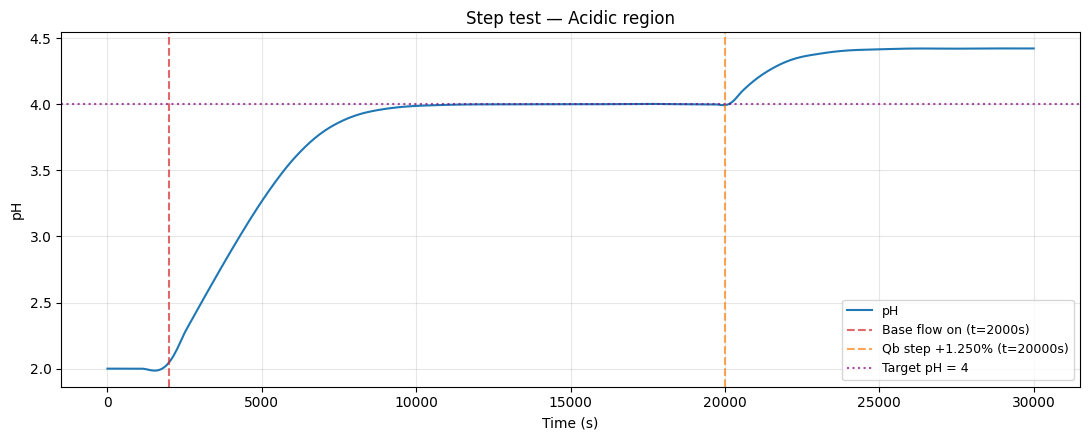

--- Acidic region (around pH 4) ---
Qb0 = 4.90099 mL/s  ->  Qb_new = 4.96225 mL/s  (+1.250%)
Process gain Kp = 6.8686 pH/(mL/s)
Time constant tau = 1276.97 s
Dead time theta = 228.24 s



In [8]:
Kp_ac, tau_ac, theta_ac = run_step_test(pH_target=4, step_pct=0.0125, Qb0_guess=0.05,
                                         region_label="Acidic")

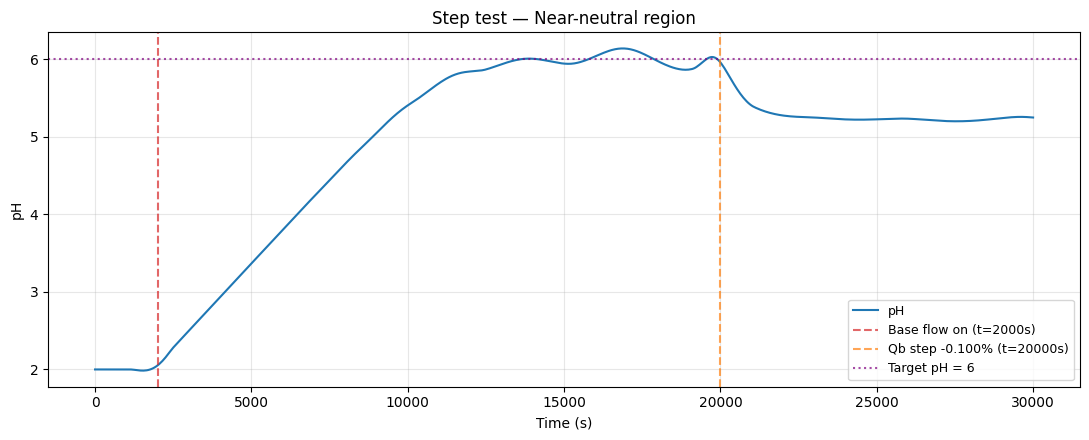

--- Near-neutral region (around pH 6) ---
Qb0 = 4.99901 mL/s  ->  Qb_new = 4.99401 mL/s  (-0.100%)
Process gain Kp = 154.2294 pH/(mL/s)
Time constant tau = 652.29 s
Dead time theta = 62.35 s



In [9]:
Kp_neu, tau_neu, theta_neu = run_step_test(pH_target=6, step_pct=-0.0010, Qb0_guess=5.0,
                                            region_label="Near-neutral")

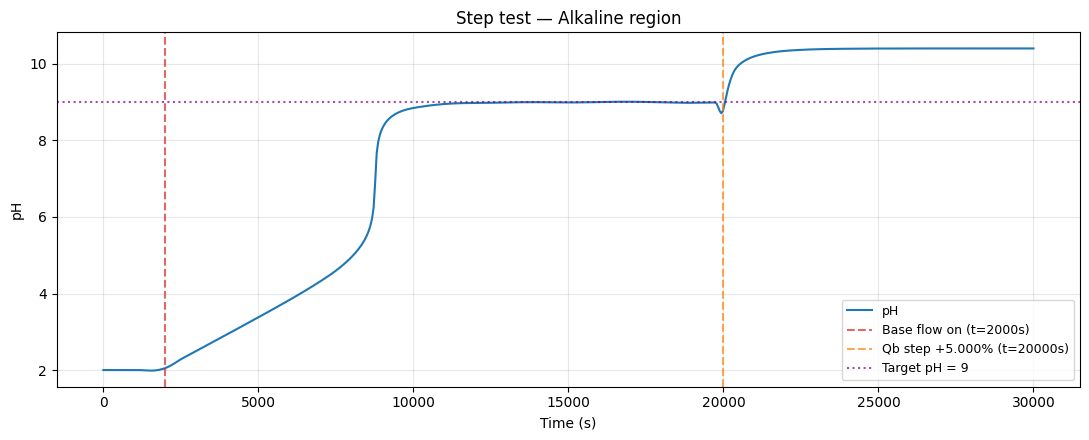

--- Alkaline region (around pH 9) ---
Qb0 = 5.01001 mL/s  ->  Qb_new = 5.26051 mL/s  (+5.000%)
Process gain Kp = 5.6066 pH/(mL/s)
Time constant tau = 367.36 s
Dead time theta = 38.21 s



In [10]:
Kp_alk, tau_alk, theta_alk = run_step_test(pH_target=9, step_pct=0.0500, Qb0_guess=5.0,
                                            region_label="Alkaline")

## Conventional PID tuning (detune approach)

A single fixed tuning based on the *average* of the three regions' FOPDT parameters
(Ziegler-Nichols open-loop / reaction-curve method). This is the "detune for the worst
case" strategy: one tuning that must remain stable everywhere, so it cannot be aggressive
anywhere.


In [11]:
Kp = (Kp_ac + Kp_neu + Kp_alk) / 3
tau = (tau_ac + tau_neu + tau_alk) / 3
theta = (theta_ac + theta_neu + theta_alk) / 3

print("--- Individual region parameters ---")
print(f"Acidic:       Kp={Kp_ac:.2f}, tau={tau_ac:.2f} s, theta={theta_ac:.2f} s")
print(f"Near-neutral: Kp={Kp_neu:.2f}, tau={tau_neu:.2f} s, theta={theta_neu:.2f} s")
print(f"Alkaline:     Kp={Kp_alk:.2f}, tau={tau_alk:.2f} s, theta={theta_alk:.2f} s")
print(f"\n--- Averaged process parameters ---")
print(f"Kp = {Kp:.2f}, tau = {tau:.2f} s, theta = {theta:.2f} s")

# Ziegler-Nichols open-loop tuning (Table 2, Modelling and Designing Controllers for pH Process)
Kc = 0.9 * tau / (Kp * theta)
tau_i = 3.33 * theta
print(f"\nZiegler-Nichols PI tuning: Kc = {Kc:.6f}, Ti = {tau_i:.2f} s")

--- Individual region parameters ---
Acidic:       Kp=6.87, tau=1276.97 s, theta=228.24 s
Near-neutral: Kp=154.23, tau=652.29 s, theta=62.35 s
Alkaline:     Kp=5.61, tau=367.36 s, theta=38.21 s

--- Averaged process parameters ---
Kp = 55.57, tau = 765.54 s, theta = 109.60 s

Ziegler-Nichols PI tuning: Kc = 0.113131, Ti = 364.96 s


### Closed-loop response — Conventional PI

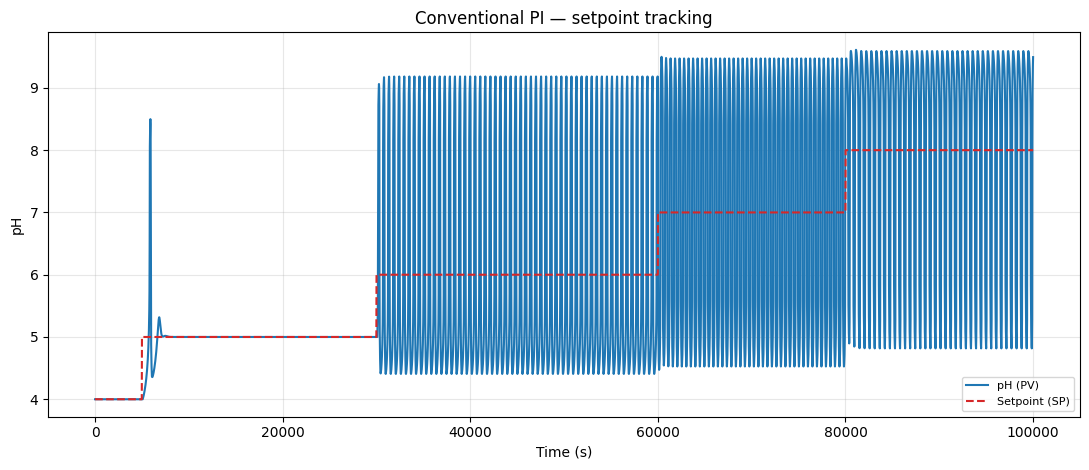

--- Conventional PI — setpoint tracking: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,5001.000,4.00 -> 5.00,1339.763,1874.204,1.063668e+06,3.498,2080.416
1,2,30006.001,5.00 -> 6.00,50879.736,108031.599,7.652191e+08,3.183,inf
2,3,60012.002,6.00 -> 7.00,42282.099,91720.999,4.224701e+08,2.499,inf
3,4,80016.003,7.00 -> 8.00,33862.012,71667.440,3.393048e+08,1.612,inf


In [12]:
result_conv = run_closed_loop_sim(
    Kc=Kc, Ti=tau_i,
    sp_events=[
        {'time': 0,     'SP': 4},
        {'time': 5000,  'SP': 5},
        {'time': 30000, 'SP': 6},
        {'time': 60000, 'SP': 7},
        {'time': 80000, 'SP': 8},
    ],
    initial_pH=4, tend=100000,
    title="Conventional PI — setpoint tracking",
)

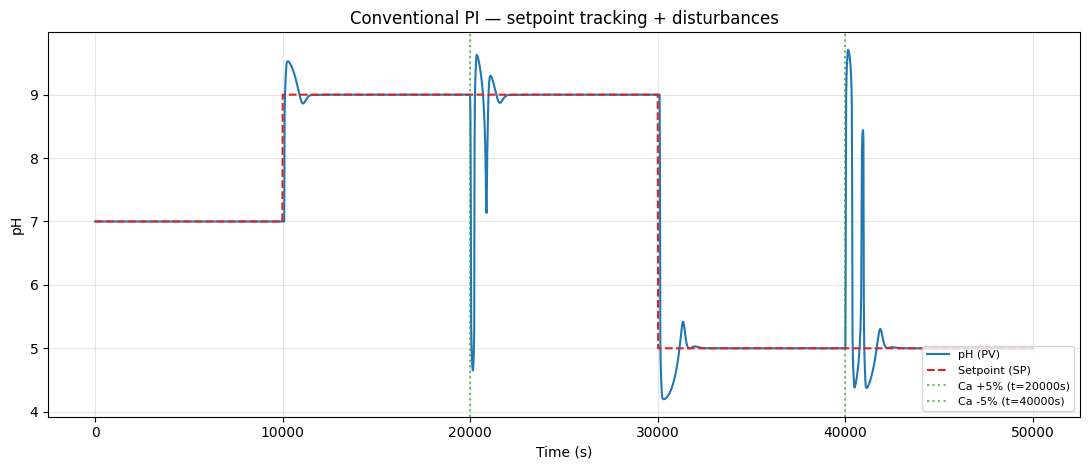

--- Conventional PI — setpoint tracking + disturbances: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,10004.002,7.00 -> 9.00,1821.689,3978.447,1.375900e+07,0.627,11804.722
1,2,30012.005,9.00 -> 5.00,3588.456,10134.061,2.611974e+07,0.804,12084.834


In [13]:
result_conv_dist = run_closed_loop_sim(
    Kc=Kc, Ti=tau_i,
    sp_events=[
        {'time': 0,     'SP': 7.0},
        {'time': 10000, 'SP': 9.0},
        {'time': 30000, 'SP': 5.0},
    ],
    dist_events=[
        {'time': 20000, 'Ca_factor': 1.05, 'label': 'Ca +5%'},
        {'time': 40000, 'Ca_factor': 0.95, 'label': 'Ca -5%'},
    ],
    initial_pH=7.0, tend=50000,
    title="Conventional PI — setpoint tracking + disturbances",
)

## IMC-based PI tuning (remove-the-nonlinearity approach)

A single fixed tuning from Internal Model Control / lambda tuning, again based on the
averaged process parameters. IMC is more conservative-by-design than Ziegler-Nichols
(the closed-loop time constant $\lambda$ is a direct tuning knob), but it is still a
*single, fixed* controller — it does not itself compensate for the process's regional
gain changes.


In [14]:
# Single source of truth for the Rivera/Morari/Skogestad IMC-PID formula, used by both
# the fixed IMC-PI tuning directly below and the regional IMC tuning further down, so the
# formula cannot drift between the two call sites again.
def imc_pid_rivera(Kp, tau, theta, lam):
    """Conventional IMC-PID (Rivera, Morari & Skogestad, 1986).
    First-order Pade approximation of the dead time. Returns (Kc, Ti, Td)."""
    Kc = (2 * tau + theta) / (Kp * (2 * lam + theta))
    Ti = tau + theta / 2
    Td = tau * theta / (2 * tau + theta)
    return Kc, Ti, Td


In [15]:
LAMBDA_MULTIPLIER = 2.25   # lam/tau = 0.32 for the averaged process parameters below
l_imc = LAMBDA_MULTIPLIER * theta

Kc_imc, Ti_imc, Td_imc = imc_pid_rivera(Kp, tau, theta, l_imc)
# Applied as a PI controller only: Td_imc is computed by the Rivera rule above but not
# used below (Td=0.0 is passed to the simulator instead). Derivative action is omitted on
# the fixed (non-scheduled) controllers because the literature reports it performing poorly
# on pH processes with significant dead time; the IMC-scheduled controller further down
# retains Td.
print(f"Kc_imc = {Kc_imc:.6f}")
print(f"Ti_imc = {Ti_imc:.2f} s")
print(f"lambda = {l_imc:.2f} s")


Kc_imc = 0.048982
Ti_imc = 820.34 s
lambda = 246.59 s


### Closed-loop response — IMC PI

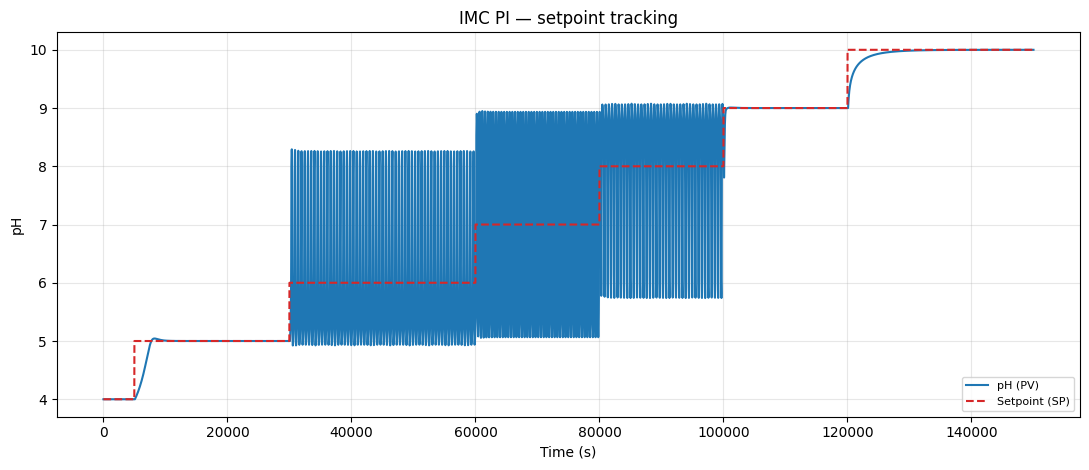

--- IMC PI — setpoint tracking: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,5000.667,4.00 -> 5.00,1592.832,1130.826,1.636233e+06,0.043,2560.341
1,2,30004.001,5.00 -> 6.00,31097.798,44093.490,4.663013e+08,2.291,inf
2,3,60008.001,6.00 -> 7.00,31512.525,52374.120,3.149552e+08,1.948,inf
3,4,80010.668,7.00 -> 8.00,20676.686,29250.813,2.069360e+08,1.075,inf
4,5,100013.335,8.00 -> 9.00,190.751,127.030,4.438034e+04,0.009,360.048
5,6,120016.002,9.00 -> 10.00,1503.872,564.247,3.735529e+06,0.000,5940.792


In [16]:
result_imc = run_closed_loop_sim(
    Kc=Kc_imc, Ti=Ti_imc,
    sp_events=[
        {'time': 0,     'SP': 4},
        {'time': 5000,  'SP': 5},
        {'time': 30000, 'SP': 6},
        {'time': 60000, 'SP': 7},
        {'time': 80000, 'SP': 8},
        {'time': 100000,'SP': 9},
        {'time': 120000,'SP': 10},
    ],
    initial_pH=4, tend=150000,
    title="IMC PI — setpoint tracking",
)

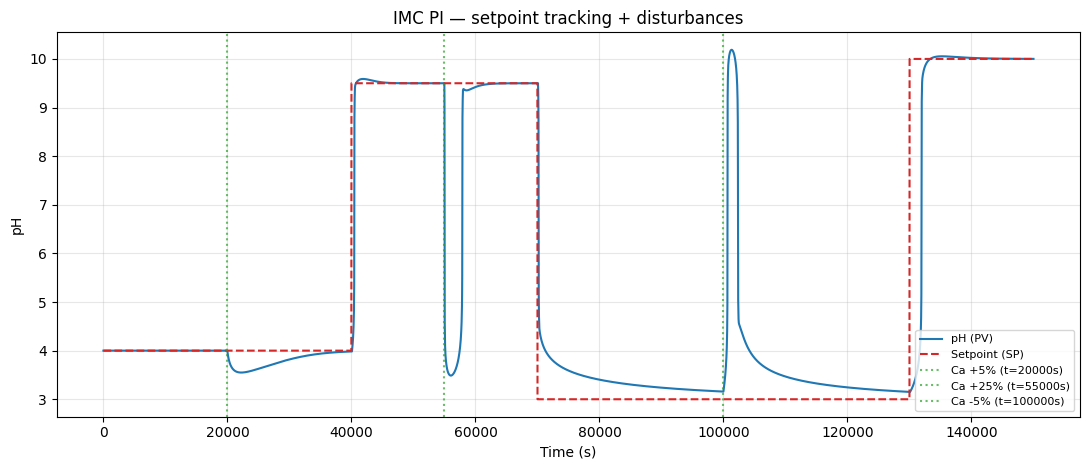

--- IMC PI — setpoint tracking + disturbances: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,40005.334,4.00 -> 9.50,19520.215,106774.507,2.783515e+08,0.089,20662.755
1,2,70009.335,9.50 -> 3.00,36417.879,102944.921,9.762865e+08,0.000,inf
2,3,130017.336,3.00 -> 10.00,13007.338,80285.660,1.463860e+07,0.054,6220.829


In [17]:
result_imc_dist = run_closed_loop_sim(
    Kc=Kc_imc, Ti=Ti_imc,
    sp_events=[
        {'time': 0,     'SP': 4.0},
        {'time': 40000, 'SP': 9.5},
        {'time': 70000, 'SP': 3.0},
        {'time': 130000,'SP': 10.0},
    ],
    dist_events=[
        {'time': 20000,  'Ca_factor': 1.05, 'label': 'Ca +5%'},
        {'time': 55000,  'Ca_factor': 1.25, 'label': 'Ca +25%'},
        {'time': 100000, 'Ca_factor': 0.95, 'label': 'Ca -5%'},
    ],
    initial_pH=4, tend=150000,
    title="IMC PI — setpoint tracking + disturbances",
)

## Frequency response and ultimate gain/period

Bode analysis of the FOPDT models (Pade-approximated dead time), computed once for the
averaged process and once per region. The ultimate gain $K_u$ and ultimate period $P_u$
(where the open-loop phase crosses $-180°$) are needed for the Ziegler-Nichols closed-loop
tuning used later to build the *pure* gain-scheduled controller.


In [18]:
def calculate_bode_data(Kp_val, tau_val, theta_val, omega_values):
    """G(s) = Kp / (tau*s + 1) * Pade(1, theta) approximation of dead time."""
    mag_term1 = Kp_val / np.sqrt(1 + (tau_val * omega_values) ** 2)
    phase_term1 = -np.arctan(tau_val * omega_values)
    phase_term2 = -2 * np.arctan(theta_val * omega_values / 2)
    return mag_term1, phase_term1 + phase_term2   # magnitude of the Pade term is 1


def find_ultimate_gain_period(Kp_val, tau_val, theta_val, omega_values):
    """Ku, Pu at the frequency where the open-loop phase crosses -180 degrees."""
    theta_val = max(1e-3, theta_val)
    magnitude, phase = calculate_bode_data(Kp_val, tau_val, theta_val, omega_values)
    crossings = np.where(np.diff(np.sign(phase + np.pi)))[0]
    if len(crossings) == 0:
        return np.nan, np.nan, magnitude, phase
    idx = crossings[0]
    w1, p1 = omega_values[idx], phase[idx]
    w2, p2 = omega_values[idx + 1], phase[idx + 1]
    omega_u = w1 + (w2 - w1) * (-np.pi - p1) / (p2 - p1)
    mag_u = np.interp(omega_u, omega_values, magnitude)
    Ku = 1 / mag_u
    Pu = 2 * np.pi / omega_u
    return Ku, Pu, magnitude, phase


omega = np.logspace(-3, 1, 500)
Ku, Pu, magnitude_avg, phase_avg = find_ultimate_gain_period(Kp, tau, theta, omega)
print(f"Averaged process: Ku = {Ku:.4f}, Pu = {Pu:.2f} s")

Averaged process: Ku = 0.2694, Pu = 322.03 s


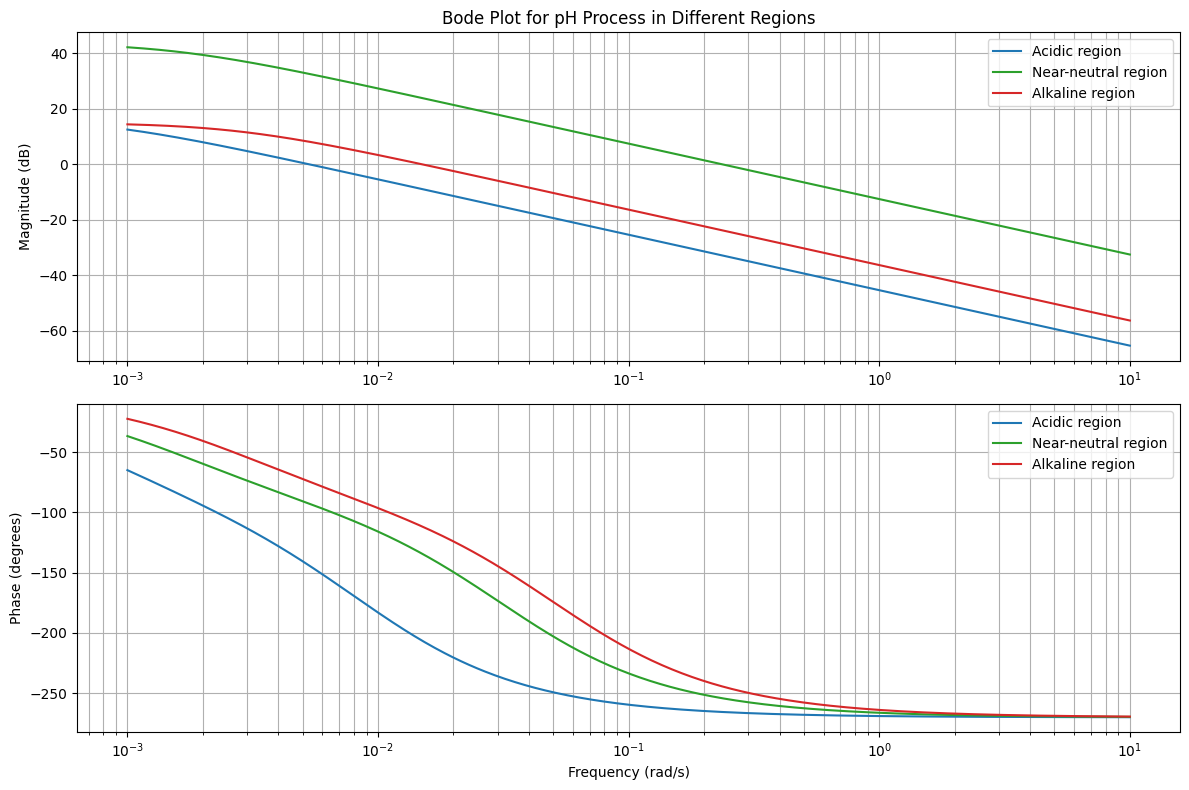

--- Ultimate gain (Ku) and ultimate period (Pu) per region ---
Acidic: Ku = 1.7747, Pu = 660.42 s
Near-neutral: Ku = 0.1421, Pu = 187.13 s
Alkaline: Ku = 3.6082, Pu = 114.24 s


In [19]:
regions = {'Acidic': (Kp_ac, tau_ac, theta_ac), 'Near-neutral': (Kp_neu, tau_neu, theta_neu),
           'Alkaline': (Kp_alk, tau_alk, theta_alk)}

bode_results = {}
for name, (Kp_r, tau_r, theta_r) in regions.items():
    bode_results[name] = find_ultimate_gain_period(Kp_r, tau_r, theta_r, omega)

Ku_ac_region, Pu_ac_region = bode_results['Acidic'][:2]
Ku_neu_region, Pu_neu_region = bode_results['Near-neutral'][:2]
Ku_alk_region, Pu_alk_region = bode_results['Alkaline'][:2]

fig, (ax_mag, ax_ph) = plt.subplots(2, 1, figsize=(12, 8))
colors = {'Acidic': 'tab:blue', 'Near-neutral': 'tab:green', 'Alkaline': 'tab:red'}
for name, (Kp_r, tau_r, theta_r) in regions.items():
    mag, ph = calculate_bode_data(Kp_r, tau_r, max(1e-3, theta_r), omega)
    ax_mag.semilogx(omega, 20 * np.log10(mag), label=f'{name} region', color=colors[name])
    ax_ph.semilogx(omega, ph * 180 / np.pi, label=f'{name} region', color=colors[name])

ax_mag.set_title('Bode Plot for pH Process in Different Regions')
ax_mag.set_ylabel('Magnitude (dB)'); ax_mag.grid(True, which='both'); ax_mag.legend()
ax_ph.set_xlabel('Frequency (rad/s)'); ax_ph.set_ylabel('Phase (degrees)')
ax_ph.grid(True, which='both'); ax_ph.legend()
plt.tight_layout(); plt.show()

print("--- Ultimate gain (Ku) and ultimate period (Pu) per region ---")
for name in regions:
    Ku_r, Pu_r = bode_results[name][:2]
    print(f"{name}: Ku = {Ku_r:.4f}, Pu = {Pu_r:.2f} s")

## IMC-scheduled PID (existing hybrid: IMC + gain scheduling)

The IMC formula is applied separately in each region to get three (Kc, Ti, Td) tunings,
which are then interpolated continuously by measured pH using the piecewise-linear
scheduler defined in the setup section. This is a **hybrid**: the underlying tuning
philosophy is still IMC/lambda tuning, just made pH-dependent.


In [20]:
# Lambda multipliers below are hand-tuned per region (chosen empirically to keep the
# near-neutral region stable) and are left unchanged here -- only named, so the values
# themselves are unambiguous. The IMC-scheduled PID stays on the Rivera rule in all three
# regions (rather than switching to Horn's improved filter, see the "Horn IMC-PI" section
# below) because the near-neutral and alkaline regions both have lambda > tau, outside
# Horn's theta < lambda < tau validity domain.
ACIDIC_LAMBDA_MULTIPLIER = 3
NEAR_NEUTRAL_LAMBDA_MULTIPLIER = 20
ALKALINE_LAMBDA_MULTIPLIER = 20

l_imc_ac = max(0.1, ACIDIC_LAMBDA_MULTIPLIER * theta_ac)
Kc_imc_ac, Ti_imc_ac, Td_imc_ac = imc_pid_rivera(Kp_ac, tau_ac, theta_ac, l_imc_ac)

l_imc_neu = max(0.1, NEAR_NEUTRAL_LAMBDA_MULTIPLIER * theta_neu)
Kc_imc_neu, Ti_imc_neu, Td_imc_neu = imc_pid_rivera(Kp_neu, tau_neu, theta_neu, l_imc_neu)

theta_alk_pos = max(1e-6, theta_alk)
l_imc_alk = max(0.1, ALKALINE_LAMBDA_MULTIPLIER * theta_alk_pos)
Kc_imc_alk, Ti_imc_alk, Td_imc_alk = imc_pid_rivera(Kp_alk, tau_alk, theta_alk_pos, l_imc_alk)

print(f"Acidic:       Kc={Kc_imc_ac:.4f}, Ti={Ti_imc_ac:.2f} s, Td={Td_imc_ac:.2f} s")
print(f"Near-neutral: Kc={Kc_imc_neu:.4f}, Ti={Ti_imc_neu:.2f} s, Td={Td_imc_neu:.2f} s")
print(f"Alkaline:     Kc={Kc_imc_alk:.4f}, Ti={Ti_imc_alk:.2f} s, Td={Td_imc_alk:.2f} s")


Acidic:       Kc=0.2535, Ti=1391.09 s, Td=104.76 s
Near-neutral: Kc=0.0035, Ti=683.46 s, Td=29.75 s
Alkaline:     Kc=0.0880, Ti=386.46 s, Td=18.16 s


In [21]:
# Breakpoints through the acidic/neutral/alkaline regions. The extra breakpoint at
# pH 7.5 (reduced Kc) accounts for the steepest part of the titration curve sitting
# just past the neutral region's identification point (pH 6).
PH_7_5_KC_MULTIPLIER = 0.36   # chosen empirically; reduces Kc through the steepest part of
                              # the titration curve, just past the pH 6 identification point
kc_breakpoints_imc = [
    (0.0, Kc_imc_ac), (5.5, Kc_imc_neu), (7.5, Kc_imc_neu * PH_7_5_KC_MULTIPLIER),
    (8.5, Kc_imc_neu), (9.5, Kc_imc_alk), (14.0, Kc_imc_alk),
]
ti_breakpoints_imc = [
    (0.0, Ti_imc_ac), (5.5, Ti_imc_ac), (7.5, Ti_imc_neu),
    (8.5, Ti_imc_neu), (9.5, Ti_imc_alk), (14.0, Ti_imc_alk),
]
td_breakpoints_imc = [
    (0.0, Td_imc_ac), (5.5, Td_imc_ac), (7.5, Td_imc_neu),
    (8.5, Td_imc_neu), (9.5, Td_imc_alk), (14.0, Td_imc_alk),
]

kc_scheduler_imc = PiecewiseLinearGainController(kc_breakpoints_imc)
ti_scheduler_imc = PiecewiseLinearGainController(ti_breakpoints_imc)
td_scheduler_imc = PiecewiseLinearGainController(td_breakpoints_imc)

print_gain_schedule_details("Kc (IMC-scheduled)", kc_breakpoints_imc)


--- Kc (IMC-scheduled) schedule (6 breakpoints) ---
  pH 0.00 to 5.50: gain = -0.0455*pH + 0.2535
  pH 5.50 to 7.50: gain = -0.0011*pH + 0.0096
  pH 7.50 to 8.50: gain = 0.0022*pH + -0.0154
  pH 8.50 to 9.50: gain = 0.0845*pH + -0.7151
  pH 9.50 to 14.00: gain = 0.0000*pH + 0.0880


### Closed-loop response — IMC-scheduled PID

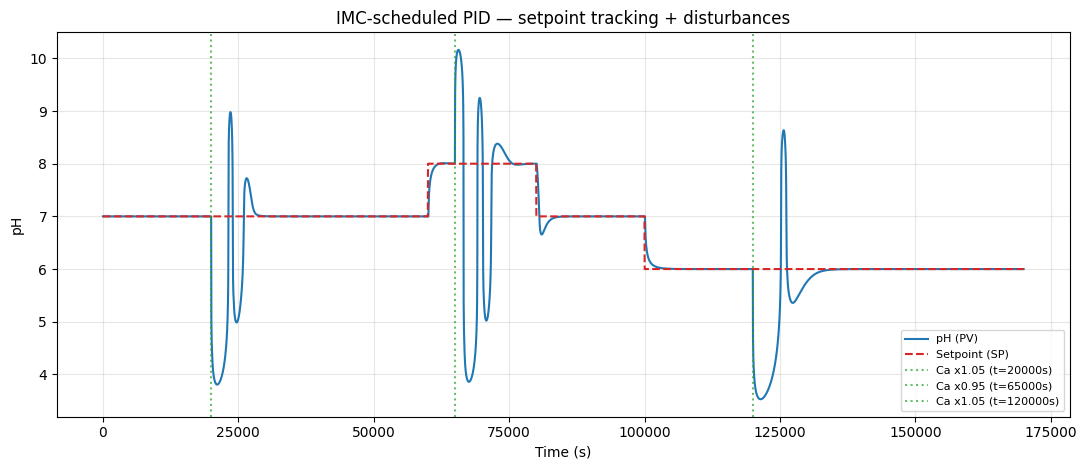

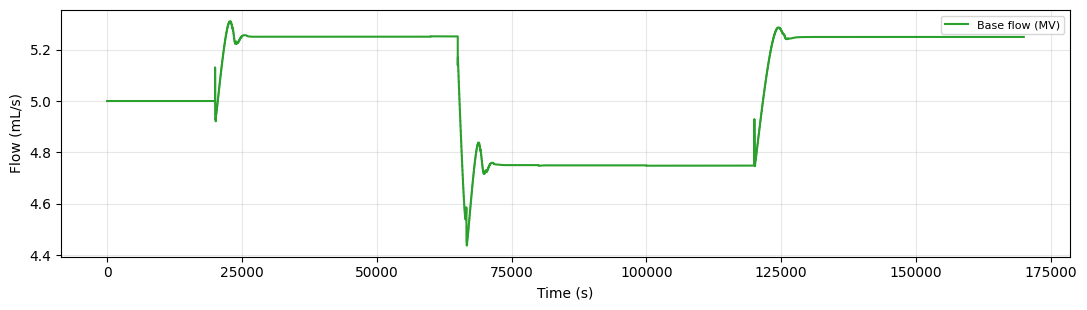

--- IMC-scheduled PID — setpoint tracking + disturbances: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,60007.060,7.00 -> 8.00,19057.620,55544.475,1.588960e+08,2.162,15101.777
1,2,80009.413,8.00 -> 7.00,854.915,409.900,8.423154e+05,0.344,2840.334
2,3,100011.766,7.00 -> 6.00,15544.388,29560.066,3.562629e+08,2.471,32423.815


In [22]:
result_imc_sched = run_closed_loop_sim(
    Kc=kc_scheduler_imc, Ti=ti_scheduler_imc, Td=td_scheduler_imc,
    sp_events=[
        {'time': 0,     'SP': 7.0},
        {'time': 60000, 'SP': 8.0},
        {'time': 80000, 'SP': 7.0},
        {'time': 100000,'SP': 6.0},
    ],
    dist_events=[
        {'time': 20000,  'Ca_factor': 1.05},
        {'time': 65000,  'Ca_factor': 0.95},
        {'time': 120000, 'Ca_factor': 1.05},
    ],
    initial_pH=7.0, tend=170000,
    title="IMC-scheduled PID — setpoint tracking + disturbances",
    show_mv=True,
)

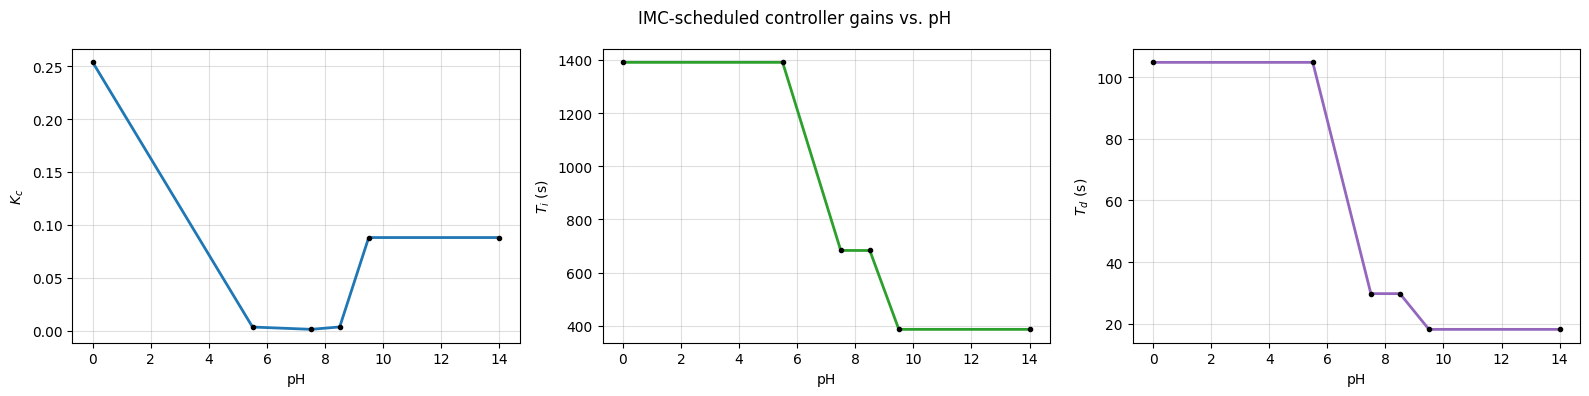

In [23]:
pH_grid = np.linspace(0, 14, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, sched, color) in zip(axes, [
        ("$K_c$", kc_scheduler_imc, 'tab:blue'),
        ("$T_i$ (s)", ti_scheduler_imc, 'tab:green'),
        ("$T_d$ (s)", td_scheduler_imc, 'tab:purple')]):
    values = [sched.calculate_gain(ph) for ph in pH_grid]
    ax.plot(pH_grid, values, color=color, lw=2)
    for x, y in sched.breakpoints:
        ax.plot(x, y, 'o', color='black', ms=3)
    ax.set_xlabel("pH"); ax.set_ylabel(name); ax.grid(alpha=0.4)
fig.suptitle("IMC-scheduled controller gains vs. pH")
plt.tight_layout(); plt.show()

## Horn IMC-PI (improved dead-time-compensating filter)

Horn et al. (1996) eq. (18)/(20): an alternative IMC filter with a phase-lead term, claimed
to improve load-disturbance rejection over the conventional Rivera/Morari/Skogestad filter
above. Same $\lambda$, $T_i$ and $T_d$ as the Rivera IMC-PI computed above -- only $K_c$
differs -- and valid only where $\theta < \lambda < \tau$ (the paper's own stated condition).


In [24]:
def imc_pid_horn(Kp, tau, theta, lam):
    """Horn et al. (1996) eq. (18) and (20): alternative phase-lead filter.
    Validity: theta < lam < tau."""
    if not (theta < lam < tau):
        raise ValueError(f"lambda={lam:.2f} outside validity range ({theta:.2f}, {tau:.2f})")
    beta = (lam**2 * theta + 2 * tau * (theta * (tau - lam) + lam * (2 * tau - lam))) \
           / (tau * (theta + 2 * tau))
    Kc = (2 * tau + theta) / (2 * (2 * lam + theta - beta) * Kp)
    Ti = tau + theta / 2
    Td = tau * theta / (2 * tau + theta)
    return Kc, Ti, Td, beta

# --- 3.1: verify against Horn et al.'s own worked example before trusting this on real data ---
_, _, _, beta_worked_example = imc_pid_horn(Kp=1, theta=10, tau=100, lam=40)
print(f"Horn worked-example check (Kp=1, theta=10, tau=100, lam=40): beta = {beta_worked_example:.2f} "
      f"(paper reports ~67.4)")
if abs(beta_worked_example - 67.4) > 0.5:
    raise AssertionError(
        "imc_pid_horn does not reproduce the paper's worked example -- stop and check eq. (18) "
        "before using this on the process data below."
    )
print("Verification passed.\n")

# --- 3.2: validity check (theta < lambda < tau) across all four existing tunings. Multipliers
# are NOT changed to force validity -- this is a genuine finding about where Horn's filter
# applies, not a defect to work around. ---
print("--- Horn improved-filter validity (theta < lambda < tau) ---")
horn_validity = {}
for label, lam_val, tau_val, theta_val in [
    ("Fixed IMC (averaged)", l_imc, tau, theta),
    ("Acidic region", l_imc_ac, tau_ac, theta_ac),
    ("Near-neutral region", l_imc_neu, tau_neu, theta_neu),
    ("Alkaline region", l_imc_alk, tau_alk, theta_alk_pos),
]:
    valid = theta_val < lam_val < tau_val
    horn_validity[label] = valid
    verdict = "yes" if valid else "no -- lambda > tau, Rivera rule applies (Horn et al.'s own criterion)"
    print(f"{label:22s} lambda/tau = {lam_val / tau_val:.2f}   Horn valid? {verdict}")

# --- 3.3: Horn IMC-PI -- same lambda/Ti/Td as the Rivera IMC-PI fixed controller above;
# only Kc differs, so filter design is the only variable between the two. Applied as a PI
# (Td=0) to match the Rivera IMC-PI controller. ---
Kc_imc_horn, _, _, beta_imc_horn = imc_pid_horn(Kp, tau, theta, l_imc)
Ti_imc_horn = Ti_imc   # identical to Rivera IMC-PI by construction
Td_imc_horn = 0.0       # PI only, to match the Rivera IMC-PI controller
print(f"\nHorn IMC-PI: Kc = {Kc_imc_horn:.6f} ({Kc_imc_horn / Kc_imc:.2f}x the Rivera IMC-PI gain), "
      f"Ti = {Ti_imc_horn:.2f} s, beta = {beta_imc_horn:.2f}")


Horn worked-example check (Kp=1, theta=10, tau=100, lam=40): beta = 67.43 (paper reports ~67.4)
Verification passed.

--- Horn improved-filter validity (theta < lambda < tau) ---
Fixed IMC (averaged)   lambda/tau = 0.32   Horn valid? yes
Acidic region          lambda/tau = 0.54   Horn valid? yes
Near-neutral region    lambda/tau = 1.91   Horn valid? no -- lambda > tau, Rivera rule applies (Horn et al.'s own criterion)
Alkaline region        lambda/tau = 2.08   Horn valid? no -- lambda > tau, Rivera rule applies (Horn et al.'s own criterion)

Horn IMC-PI: Kc = 0.103940 (2.12x the Rivera IMC-PI gain), Ti = 820.34 s, beta = 460.75


### Rivera vs Horn IMC-PI — same-scenario comparison

The two fixed-IMC controllers run on exactly the scenarios already used for the Rivera
IMC-PI above (pure setpoint tracking, then setpoint tracking + disturbances), so filter
design is the only variable between the paired runs.


In [25]:
# Direct Rivera-vs-Horn comparison on the SAME two scenarios already used for the Rivera
# IMC-PI controller above (pure setpoint tracking, then setpoint tracking + disturbances),
# so filter design is the only thing that differs between the paired runs. plot=False here
# since the point is the per-step metrics tables (printed below), not new figures.
result_imc_horn = run_closed_loop_sim(
    Kc=Kc_imc_horn, Ti=Ti_imc_horn, Td=Td_imc_horn,
    sp_events=[
        {'time': 0,     'SP': 4},
        {'time': 5000,  'SP': 5},
        {'time': 30000, 'SP': 6},
        {'time': 60000, 'SP': 7},
        {'time': 80000, 'SP': 8},
        {'time': 100000,'SP': 9},
        {'time': 120000,'SP': 10},
    ],
    initial_pH=4, tend=150000,
    title="Horn IMC-PI — setpoint tracking",
    plot=False,
)

result_imc_horn_dist = run_closed_loop_sim(
    Kc=Kc_imc_horn, Ti=Ti_imc_horn, Td=Td_imc_horn,
    sp_events=[
        {'time': 0,     'SP': 4.0},
        {'time': 40000, 'SP': 9.5},
        {'time': 70000, 'SP': 3.0},
        {'time': 130000,'SP': 10.0},
    ],
    dist_events=[
        {'time': 20000,  'Ca_factor': 1.05, 'label': 'Ca +5%'},
        {'time': 55000,  'Ca_factor': 1.25, 'label': 'Ca +25%'},
        {'time': 100000, 'Ca_factor': 0.95, 'label': 'Ca -5%'},
    ],
    initial_pH=4, tend=150000,
    title="Horn IMC-PI — setpoint tracking + disturbances",
    plot=False,
)


--- Horn IMC-PI — setpoint tracking: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,5000.667,4.00 -> 5.00,833.614,581.215,4.852205e+05,0.093,1760.235
1,2,30004.001,5.00 -> 6.00,45954.270,91689.700,6.899298e+08,2.965,inf
2,3,60008.001,6.00 -> 7.00,40096.585,82706.724,4.003461e+08,2.376,inf
3,4,80010.668,7.00 -> 8.00,30647.863,61051.508,3.065546e+08,1.495,inf
4,5,100013.335,8.00 -> 9.00,78.870,20.663,1.343785e+04,0.471,340.045
5,6,120016.002,9.00 -> 10.00,698.269,298.084,6.740787e+05,0.000,2620.349


--- Horn IMC-PI — setpoint tracking + disturbances: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,40005.334,4.00 -> 9.50,9738.025,44250.718,1.269384e+08,0.297,19842.646
1,2,70009.335,9.50 -> 3.00,18374.736,25907.408,4.514423e+08,0.000,58607.814
2,3,130017.336,3.00 -> 10.00,8789.990,51752.758,8.361840e+06,0.211,7180.957


## Pure gain-scheduled PID (new: classical, IMC-independent gain scheduling)

This is a genuinely distinct third design philosophy, completing the taxonomy the report's
introduction sets up (detune / remove-the-nonlinearity via IMC / **gain-schedule**), and it
does not depend on the IMC framework at all.

**Idea.** The process's steady-state gain $K_p(\mathrm{pH})$ is exactly the local slope of
the titration curve, $d(\mathrm{pH})/dQ_b$, which is already available from the titration
curve computed above. A classical gain-scheduled controller compensates for this directly:
it schedules $K_c(\mathrm{pH})$ so that the *loop gain* $K_c(\mathrm{pH}) \cdot K_p(\mathrm{pH})$
stays approximately constant across the operating range —

$$K_c(\mathrm{pH}) = K_{c,\text{ref}} \cdot \frac{K_p(\mathrm{pH_{ref}})}{K_p(\mathrm{pH})}$$

with the reference tuning $K_{c,\text{ref}}$ coming from a conservative fraction of the
near-neutral region's ultimate gain $K_u$ (a Ziegler-Nichols-family rule) rather than from
IMC, and the schedule clipped to a bounded multiple of $K_{c,\text{ref}}$ so it cannot
extrapolate to an arbitrarily large gain outside the region the process was actually
identified in. $T_i$ is held **fixed** at that same reference tuning ($T_d = 0$: PI only,
which also avoids differentiating a pH signal that is, by construction, most sensitive to
noise exactly where the schedule is most active) — only the proportional gain is
scheduled. This is the classical textbook scheme for a process whose nonlinearity is
dominated by a changing steady-state gain (Shinskey; Kalafatis et al., 1992).


In [26]:
# Local process gain Kp(pH) = d(pH)/dQb, read directly off the titration curve.
titration_gain = np.gradient(titration_pH, titration_Qb)

# Floor the gain so Kc doesn't blow up in the flat, far-from-equivalence regions.
gain_floor = 0.05 * np.max(titration_gain)
titration_gain_clipped = np.clip(titration_gain, gain_floor, None)

def kp_from_titration(pH_query):
    """Continuous process gain estimate at pH_query, from the titration curve slope."""
    return np.interp(pH_query, titration_pH, titration_gain_clipped)

# Reference tuning: a conservative fraction of the near-neutral region's ultimate gain Ku
# -- independent of the IMC lambda-tuning used elsewhere in this notebook. The near-neutral
# region is deliberately used as the reference because it is the *least* robust region
# (lowest Ku of the three -- see the Bode/Ku,Pu section): a schedule that is safe there and
# then scaled down further at more forgiving operating points is the conservative choice.
# (0.6*Ku / Pu/2, the standard Ziegler-Nichols closed-loop PID rule, was tried first and is
# too aggressive here -- see the discussion below the closed-loop response.)
pH_ref = 7.0
Kc_zn_ref = 0.2 * Ku_neu_region
Ti_zn_ref = 2.0 * Pu_neu_region
Td_zn_ref = 0.0   # PI only -- see note above
print(f"Reference tuning at pH {pH_ref}: Kc = {Kc_zn_ref:.4f}, Ti = {Ti_zn_ref:.2f} s")

# Validate the titration-curve gain estimate against the independent step-test estimates
print("\n--- Cross-check: titration-curve slope vs. step-test Kp ---")
for label, pH_pt, Kp_step in [("Acidic", 4, Kp_ac), ("Near-neutral", 6, Kp_neu), ("Alkaline", 9, Kp_alk)]:
    print(f"{label:13s} pH={pH_pt}: titration slope = {kp_from_titration(pH_pt):.4f}, "
          f"step-test Kp = {Kp_step:.4f}")

Reference tuning at pH 7.0: Kc = 0.0284, Ti = 374.25 s

--- Cross-check: titration-curve slope vs. step-test Kp ---
Acidic        pH=4: titration slope = 12.3266, step-test Kp = 6.8686
Near-neutral  pH=6: titration slope = 244.7798, step-test Kp = 154.2294
Alkaline      pH=9: titration slope = 86.9409, step-test Kp = 5.6066


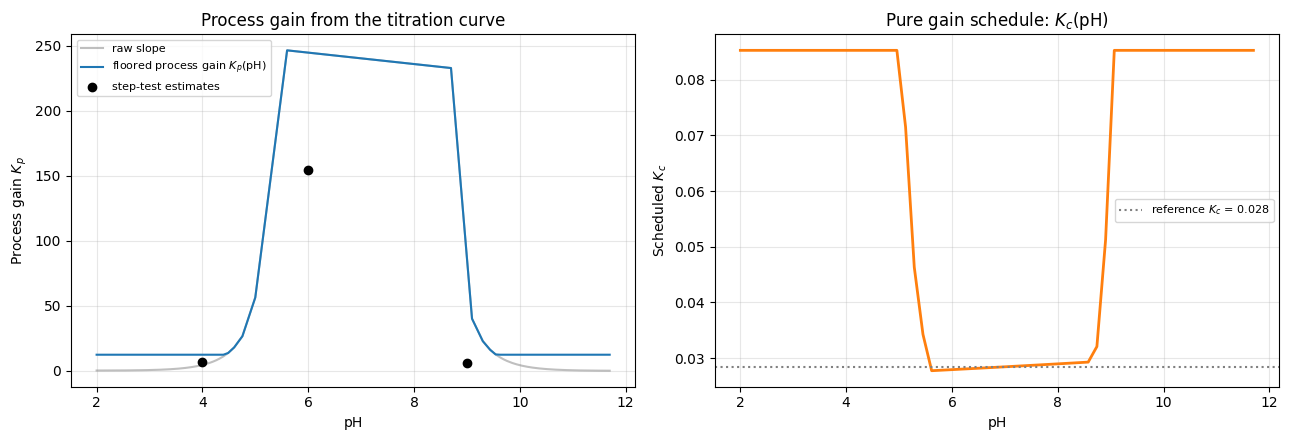

In [27]:
kp_ref = kp_from_titration(pH_ref)
pH_schedule_grid = np.linspace(titration_pH.min(), titration_pH.max(), 60)
kc_values_pure_raw = Kc_zn_ref * kp_ref / kp_from_titration(pH_schedule_grid)
# Bound the schedule to a fixed multiple of the reference gain: naive gain scheduling that
# freely extrapolates from a single reference point is exactly the failure mode Leith &
# Leithead (2000) warn about (see discussion below).
cap_multiple = 3.0
kc_values_pure = np.clip(kc_values_pure_raw, Kc_zn_ref / cap_multiple, Kc_zn_ref * cap_multiple)

kc_scheduler_pure = PiecewiseLinearGainController(list(zip(pH_schedule_grid, kc_values_pure)))
# Ti, Td are fixed at the ZN reference tuning -- only Kc is scheduled.
Ti_pure = Ti_zn_ref
Td_pure = Td_zn_ref

# The schedule is looked up on a filtered pH rather than the raw measurement (a standard
# practical safeguard for gain scheduling on a fast/noisy PV): right at equivalence the
# titration curve's slope changes so quickly that scheduling on the raw signal makes the
# schedule itself part of the feedback loop and can self-excite a limit cycle as pH
# crosses the steep region. A ~1-minute filter (comparable to a real pH transmitter's
# damping setting) removes that without materially slowing the controller's response to
# genuine, sustained operating-point changes.
schedule_filter_tau = 60.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(titration_pH, titration_gain, color='gray', alpha=0.5, label='raw slope')
ax1.plot(titration_pH, titration_gain_clipped, color='tab:blue', label='floored process gain $K_p$(pH)')
ax1.scatter([4, 6, 9], [Kp_ac, Kp_neu, Kp_alk], color='black', zorder=5, label='step-test estimates')
ax1.set_xlabel("pH"); ax1.set_ylabel("Process gain $K_p$"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("Process gain from the titration curve")

ax2.plot(pH_schedule_grid, kc_values_pure, color='tab:orange', lw=2)
ax2.axhline(Kc_zn_ref, color='gray', ls=':', label=f'reference $K_c$ = {Kc_zn_ref:.3f}')
ax2.set_xlabel("pH"); ax2.set_ylabel("Scheduled $K_c$"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
ax2.set_title("Pure gain schedule: $K_c$(pH)")
plt.tight_layout(); plt.show()

### Closed-loop response — Pure gain-scheduled PID

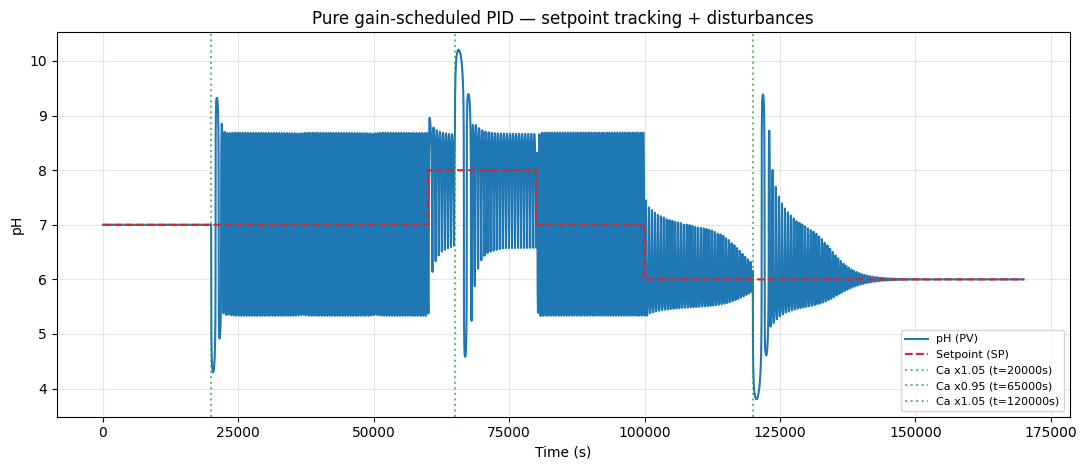

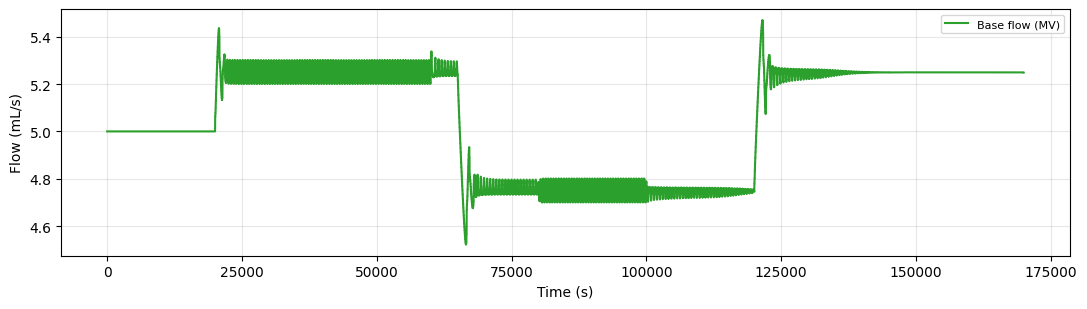

--- Pure gain-scheduled PID — setpoint tracking + disturbances: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,60007.060,7.00 -> 8.00,17052.379,24324.908,1.491721e+08,2.205,inf
1,2,80009.413,8.00 -> 7.00,26645.449,37799.188,2.674059e+08,1.670,inf
2,3,100011.766,7.00 -> 6.00,20337.634,22107.943,3.869077e+08,2.195,42104.954


In [28]:
result_pure_sched = run_closed_loop_sim(
    Kc=kc_scheduler_pure, Ti=Ti_pure, Td=Td_pure,
    sp_events=[
        {'time': 0,     'SP': 7.0},
        {'time': 60000, 'SP': 8.0},
        {'time': 80000, 'SP': 7.0},
        {'time': 100000,'SP': 6.0},
    ],
    dist_events=[
        {'time': 20000,  'Ca_factor': 1.05},
        {'time': 65000,  'Ca_factor': 0.95},
        {'time': 120000, 'Ca_factor': 1.05},
    ],
    initial_pH=7.0, tend=170000,
    schedule_filter_tau=schedule_filter_tau,
    title="Pure gain-scheduled PID — setpoint tracking + disturbances",
    show_mv=True,
)

### Why this controller is *not* simply the best of the four

The pure gain-scheduled controller compensates for the process's steady-state
(DC) gain nonlinearity, and only that. It has no way to know that the near-neutral
region is also where the process is *fastest and least damped* relative to the fixed
$T_i$ it inherited from the reference tuning, nor does it react any faster than a fixed
controller to a disturbance that hits while sitting exactly at the equivalence point
(where the titration curve has essentially zero buffering capacity — see the very first
setpoint segment below, immediately after the $t=20000\,\mathrm{s}$ feed disturbance).

This is precisely the limitation Leith & Leithead's 2000 survey raises about naive
gain scheduling: a schedule built from a family of *frozen-operating-point* linearisations
(here, the steady-state gain curve) does not, by construction, say anything about the
nonlinear system's actual transient/disturbance behaviour as the operating point moves —
good local linear designs do not automatically compose into a good global nonlinear one.
The IMC-scheduled controller above sidesteps part of this by scheduling $T_i$ (and $T_d$)
as well as $K_c$, using region-specific dynamic (not just steady-state) information; this
pure controller deliberately does not, so the comparison below is also an empirical
illustration of that theoretical gap — worth citing explicitly next to Kalafatis et al.
(1992) in the report's gain-scheduling subsection, rather than leaving Leith & Leithead's
survey uncited despite sitting in the project's own reference library.


## Controller comparison summary

All four controllers, run under the **same** standardized scenario (setpoint sequence +
feed-concentration disturbances), so their IAE / ISE / ITAE / overshoot / settling-time
figures are directly comparable. This table is the one to pull into the report's Results
section.


In [29]:
comparison_scenario = dict(
    sp_events=[
        {'time': 0,     'SP': 7.0},
        {'time': 60000, 'SP': 8.0},
        {'time': 80000, 'SP': 7.0},
        {'time': 100000,'SP': 6.0},
    ],
    dist_events=[
        {'time': 20000,  'Ca_factor': 1.05},
        {'time': 65000,  'Ca_factor': 0.95},
        {'time': 120000, 'Ca_factor': 1.05},
    ],
    initial_pH=7.0, tend=170000,
)

controllers = {
    'Conventional PI':     dict(Kc=Kc, Ti=tau_i, Td=0.0),
    'IMC PI':              dict(Kc=Kc_imc, Ti=Ti_imc, Td=0.0),  # Td=0.0: PI only -- see "IMC-based PI tuning" section
    'Horn IMC-PI':         dict(Kc=Kc_imc_horn, Ti=Ti_imc_horn, Td=Td_imc_horn),
    'IMC-scheduled PID':   dict(Kc=kc_scheduler_imc, Ti=ti_scheduler_imc, Td=td_scheduler_imc),
    'Pure gain-scheduled PID': dict(Kc=kc_scheduler_pure, Ti=Ti_pure, Td=Td_pure,
                                     schedule_filter_tau=schedule_filter_tau),
}

all_rows = []
for name, params in controllers.items():
    res = run_closed_loop_sim(**params, **comparison_scenario, title=name, plot=False)
    df = res['metrics_df'].copy()
    df.insert(0, 'Controller', name)
    all_rows.append(df)

comparison_df = pd.concat(all_rows, ignore_index=True)
comparison_df


--- Conventional PI: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,60007.060,7.00 -> 8.00,34532.506,73755.354,3.414833e+08,2.130,inf
1,2,80009.413,8.00 -> 7.00,42327.443,91929.331,4.225115e+08,2.520,inf
2,3,100011.766,7.00 -> 6.00,119077.033,252397.318,4.166434e+09,2.015,inf


--- IMC PI: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,60007.060,7.00 -> 8.00,25560.165,43381.804,2.404737e+08,2.376,inf
1,2,80009.413,8.00 -> 7.00,31496.274,52667.402,3.142728e+08,1.965,inf
2,3,100011.766,7.00 -> 6.00,77005.321,115841.031,2.631496e+09,2.370,inf


--- Horn IMC-PI: performance per setpoint step ---


...

--- IMC-scheduled PID: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,60007.060,7.00 -> 8.00,19057.620,55544.475,1.588960e+08,2.162,15101.777
1,2,80009.413,8.00 -> 7.00,854.915,409.900,8.423154e+05,0.344,2840.334
2,3,100011.766,7.00 -> 6.00,15544.388,29560.066,3.562629e+08,2.471,32423.815


--- Pure gain-scheduled PID: performance per setpoint step ---


,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,1,60007.060,7.00 -> 8.00,17052.379,24324.908,1.491721e+08,2.205,inf
1,2,80009.413,8.00 -> 7.00,26645.449,37799.188,2.674059e+08,1.670,inf
2,3,100011.766,7.00 -> 6.00,20337.634,22107.943,3.869077e+08,2.195,42104.954


,Controller,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,Conventional PI,1,60007.060,7.00 -> 8.00,34532.506,73755.354,3.414833e+08,2.130,inf
1,Conventional PI,2,80009.413,8.00 -> 7.00,42327.443,91929.331,4.225115e+08,2.520,inf
2,Conventional PI,3,100011.766,7.00 -> 6.00,119077.033,252397.318,4.166434e+09,2.015,inf
3,IMC PI,1,60007.060,7.00 -> 8.00,25560.165,43381.804,2.404737e+08,2.376,inf
4,IMC PI,2,80009.413,8.00 -> 7.00,31496.274,52667.402,3.142728e+08,1.965,inf
5,IMC PI,3,100011.766,7.00 -> 6.00,77005.321,115841.031,2.631496e+09,2.370,inf
6,Horn IMC-PI,1,60007.060,7.00 -> 8.00,31454.961,61752.749,3.120906e+08,2.093,inf
7,Horn IMC-PI,2,80009.413,8.00 -> 7.00,40063.137,82634.869,4.000632e+08,2.376,inf
8,Horn IMC-PI,3,100011.766,7.00 -> 6.00,108554.250,215692.877,3.780474e+09,2.179,inf
9,IMC-scheduled PID,1,60007.060,7.00 -> 8.00,19057.620,55544.475,1.588960e+08,2.162,15101.777


In [30]:
summary_df = (comparison_df.groupby('Controller')[['IAE', 'ISE', 'ITAE', 'Overshoot (pH)']]
              .mean().round(3))
summary_df['Worst settling time (s)'] = (
    comparison_df.replace({'Settling time (s)': {np.inf: np.nan}})
    .groupby('Controller')['Settling time (s)'].max()
)
# A step that never settles becomes NaN above (via the inf -> NaN replacement) and would
# otherwise look like missing data. It is a real result, so report it explicitly as a count.
summary_df['Steps not settled'] = (
    comparison_df.groupby('Controller')['Settling time (s)']
    .apply(lambda s: int(np.isinf(s).sum()))
)
summary_df = summary_df.reindex(list(controllers.keys()))
print("--- Mean performance across all setpoint steps, same scenario ---")
summary_df


--- Mean performance across all setpoint steps, same scenario ---


,IAE,ISE,ITAE,Overshoot (pH),Worst settling time (s),Steps not settled
Controller,,,,,,
Conventional PI,65312.327,139360.668,1.643476e+09,2.222,NaN,3
IMC PI,44687.253,70630.079,1.062081e+09,2.237,NaN,3
Horn IMC-PI,60024.116,120026.832,1.497542e+09,2.216,NaN,3
IMC-scheduled PID,11818.974,28504.814,1.720004e+08,1.659,32423.815,0
Pure gain-scheduled PID,21345.154,28077.346,2.678286e+08,2.023,42104.954,2


### Reading the comparison

* **Conventional PI** is tuned to be safe everywhere, so it is typically the slowest /
  most sluggish of the four in the regions where the process gain is actually low, and the
  least aggressive near equivalence.
* **IMC PI** trades the Ziegler-Nichols rule for a lambda-tuning rule, usually a smoother,
  less oscillatory single fixed response — but it's still one tuning for the whole range.
* **IMC-scheduled PID** and **Pure gain-scheduled PID** should both improve on the two fixed
  controllers by adapting to the local process gain, but for different reasons: the IMC-
  scheduled controller changes *which IMC lambda-tuning* applies, while the pure
  gain-scheduled controller directly compensates the measured process nonlinearity and
  keeps $T_i$/$T_d$ fixed. Comparing their overshoot and settling time next to each other,
  particularly on the step through the steep near-equivalence region (pH 7→8), is the
  most direct evidence for which mechanism is doing the work.


## Robustness to plant-model mismatch

Every controller above was designed (identified, tuned, scheduled) from the *nominal*
process model — the constants `Qa`, `Ca`, `Cb`, `V` defined in the Shared setup section, and
the FOPDT parameters fitted from step tests run on that same nominal model. In practice the
real plant never matches its model exactly: reagent concentrations drift, the reactor volume
is only known to some tolerance, sensors and actuators have their own uncertainty. A
controller design is only as good as its ability to keep performing acceptably when the real
process is *not quite* what it was designed against — that ability is what "robustness"
means here, and it is measured two ways below:

1. **Stability margins (frequency domain).** For each controller's fixed (or scheduled)
   tuning, the classical gain margin (GM) and phase margin (PM) of the loop
   $L(j\omega) = C(j\omega) \cdot G(j\omega)$ against each region's identified FOPDT model —
   how much extra loop gain or phase lag the closed loop can absorb before it goes unstable,
   evaluated with the same models used to design the controller in the first place.
2. **Simulated performance under plant-model mismatch (time domain).** The same
   standardized comparison scenario used in *Controller comparison summary* above, but run
   against a "true" plant whose physical constants (`V`, `Ca`, `Cb`) are perturbed away from
   the nominal values the controllers were designed with — while every controller's tuning
   is left exactly as designed, since a real controller has no way to know the plant has
   changed. Performance degradation relative to the nominal-model run is the robustness
   measure.


In [31]:
# ============================================================
# STABILITY MARGINS (gain margin / phase margin)
# ============================================================
# Reuses calculate_bode_data (Shared setup / Frequency response section) for the process
# side of the loop, and adds the standard ISA-form PI/PID controller frequency response
# for the controller side, so the two combine into a single loop transfer function
# L(jw) = C(jw) * G(jw) whose margins can be read off exactly as in a textbook Bode/Nyquist
# stability analysis. Margins are evaluated on a dedicated, much wider frequency grid than
# the Frequency response section's `omega` above: some of the scheduled tunings below have
# very low proportional gain (deliberately, see the Kc breakpoints), which pushes their
# gain-crossover frequency far below 1e-3 rad/s -- outside `omega`'s range -- even though
# the process itself is unchanged.

omega_margins = np.logspace(-7, 3, 8000)


def pid_freq_response(Kc, Ti, Td, omega_values):
    """C(jw) magnitude and phase for the standard ISA-form PID controller
    C(s) = Kc*(1 + 1/(Ti*s) + Td*s). Ti is assumed > 0 (true for every tuning above)."""
    imag_part = Td * omega_values - 1.0 / (Ti * omega_values)
    magnitude = Kc * np.sqrt(1 + imag_part ** 2)
    phase = np.arctan(imag_part)
    return magnitude, phase


def _eval_param(val, pH):
    """Resolve a possibly-scheduled controller parameter at a given pH -- same rule the
    closed-loop simulator uses (see `scheduled(...)` inside run_closed_loop_sim)."""
    return val.calculate_gain(pH) if isinstance(val, PiecewiseLinearGainController) else val


def find_margins(Kc, Ti, Td, Kp_val, tau_val, theta_val, omega_values):
    """Gain margin (dB, np.inf if the loop phase never reaches -180 deg over
    omega_values -- i.e. no amount of extra gain destabilises it at this frequency
    resolution) and phase margin (deg) of the loop L = C*G, for a controller
    (Kc, Ti, Td) acting on an FOPDT model (Kp, tau, theta)."""
    mag_G, phase_G = calculate_bode_data(Kp_val, tau_val, max(1e-3, theta_val), omega_values)
    mag_C, phase_C = pid_freq_response(Kc, Ti, max(Td, 0.0), omega_values)
    mag_L = mag_G * mag_C
    phase_L = phase_G + phase_C
    mag_L_dB = 20 * np.log10(mag_L)

    # Phase margin: at the gain-crossover frequency, |L| = 1 (0 dB).
    gc_cross = np.where(np.diff(np.sign(mag_L_dB)))[0]
    if len(gc_cross) == 0:
        PM = np.nan
    else:
        idx = gc_cross[0]
        w1, m1 = omega_values[idx], mag_L_dB[idx]
        w2, m2 = omega_values[idx + 1], mag_L_dB[idx + 1]
        w_gc = w1 + (w2 - w1) * (0 - m1) / (m2 - m1)
        phase_at_gc = np.interp(w_gc, omega_values, phase_L)
        PM = 180 + phase_at_gc * 180 / np.pi

    # Gain margin: at the phase-crossover frequency, phase = -180 deg. With a Pade-
    # approximated dead time and enough derivative action, phase_L can approach -180 deg
    # asymptotically as omega -> inf without ever crossing it -- a genuine (if idealised)
    # "unconditionally stable at this operating point" result, not a bug -- so that case is
    # reported as GM = +inf rather than NaN.
    pc_cross = np.where(np.diff(np.sign(phase_L + np.pi)))[0]
    if len(pc_cross) == 0:
        GM_dB = np.inf if phase_L.min() > -np.pi else np.nan
    else:
        idx = pc_cross[0]
        w1, p1 = omega_values[idx], phase_L[idx]
        w2, p2 = omega_values[idx + 1], phase_L[idx + 1]
        w_pc = w1 + (w2 - w1) * (-np.pi - p1) / (p2 - p1)
        mag_at_pc = np.interp(w_pc, omega_values, mag_L)
        GM_dB = -20 * np.log10(mag_at_pc)

    return GM_dB, PM


### Gain and phase margins by controller and region

Each controller is evaluated against **all three** regions' identified FOPDT models, not
just the region its tuning came from — this is exactly how plant-model mismatch shows up for
a controller that is only *locally* correct: the Conventional PI and IMC PI tunings are
fixed everywhere, so their margins vary a lot from region to region; the two scheduled
controllers should hold much more even margins, because their gains are evaluated at the
scheduled value for that region's operating pH rather than a single fixed tuning.


In [32]:
region_pH = {'Acidic': 4, 'Near-neutral': 6, 'Alkaline': 9}

margin_rows = []
for cname, params in controllers.items():
    Kc_c, Ti_c, Td_c = params['Kc'], params['Ti'], params['Td']
    for rname, (Kp_r, tau_r, theta_r) in regions.items():
        ph_r = region_pH[rname]
        Kc_eval = _eval_param(Kc_c, ph_r)
        Ti_eval = _eval_param(Ti_c, ph_r)
        Td_eval = _eval_param(Td_c, ph_r)
        GM_dB, PM = find_margins(Kc_eval, Ti_eval, Td_eval, Kp_r, tau_r, theta_r, omega_margins)
        margin_rows.append({
            'Controller': cname, 'Region': rname,
            'Kc (evaluated)': Kc_eval, 'Ti (s)': Ti_eval, 'Td (s)': Td_eval,
            'Gain margin (dB)': GM_dB, 'Phase margin (deg)': PM,
        })

margins_df = pd.DataFrame(margin_rows).round(3)
print("--- Gain margin (dB) / phase margin (deg), each controller vs. each region's FOPDT model ---")
try:
    from IPython.display import display
    display(margins_df)
except Exception:
    print(margins_df.to_string(index=False))


--- Gain margin (dB) / phase margin (deg), each controller vs. each region's FOPDT model ---


,Controller,Region,Kc (evaluated),Ti (s),Td (s),Gain margin (dB),Phase margin (deg)
0,Conventional PI,Acidic,0.113,364.959,0.000,20.134,40.431
1,Conventional PI,Near-neutral,0.113,364.959,0.000,1.216,7.591
2,Conventional PI,Alkaline,0.113,364.959,0.000,29.631,86.034
3,IMC PI,Acidic,0.049,820.336,0.000,29.936,76.290
4,IMC PI,Near-neutral,0.049,820.336,0.000,8.936,51.950
5,IMC PI,Alkaline,0.049,820.336,0.000,37.156,97.827
6,Horn IMC-PI,Acidic,0.104,820.336,0.000,23.401,68.227
7,Horn IMC-PI,Near-neutral,0.104,820.336,0.000,2.401,15.856
8,Horn IMC-PI,Alkaline,0.104,820.336,0.000,30.621,105.365
9,IMC-scheduled PID,Acidic,0.072,1391.086,104.756,inf,87.686


### Simulated robustness to parametric plant-model mismatch

Time-domain complement to the margins above: the same `comparison_scenario` and the same
four controller tunings from *Controller comparison summary*, but the closed-loop simulator
below lets the *true* plant's physical constants (`Qa`, `Ca`, `Cb`, `V`) differ from the
nominal values (`Qa`, `Ca`, `Cb`, `V` from Shared setup) that every controller in this
notebook was identified and tuned against. The controller has no knowledge of the mismatch —
it only ever measures pH — so any performance change is purely the effect of plant-model
mismatch on a fixed design.


In [33]:
# ============================================================
# CLOSED-LOOP SIMULATOR WITH PLANT-MODEL MISMATCH
# ============================================================
# Identical to run_closed_loop_sim (Shared setup) except that the physical constants
# governing the *actual* process integrated forward in time can be overridden independently
# of the nominal Qa/Ca/Cb/V the controllers above were designed against. Any *_true left as
# None falls back to the nominal value, so calling this with no *_true arguments reproduces
# run_closed_loop_sim exactly.

def run_closed_loop_sim_mismatch(Kc, Ti, Td=0.0, sp_events=None, dist_events=None,
                                  initial_pH=None, theta_dead=None,
                                  Qa_true=None, Ca_true=None, Cb_true=None, V_true=None,
                                  F_min=0.0, F_max=None, tend=100000, n_points=None,
                                  schedule_filter_tau=0.0,
                                  title="Closed-Loop pH Control (plant-model mismatch)",
                                  show_mv=False, plot=True):
    Qa_p = Qa if Qa_true is None else Qa_true
    Ca_p = Ca if Ca_true is None else Ca_true
    Cb_p = Cb if Cb_true is None else Cb_true
    V_p = V if V_true is None else V_true

    if not sp_events:
        raise ValueError("sp_events must be a non-empty list, e.g. [{'time': 0, 'SP': 7.0}]")
    dist_events = dist_events or []
    theta_dead = theta if theta_dead is None else theta_dead
    # Actuator (pump) flow limit is a hardware property, not a plant-model parameter -- kept
    # at the nominal value regardless of the true-plant mismatch being tested.
    F_max = default_F_max() if F_max is None else F_max

    if n_points is None:
        n_points = max(800, int(tend / 20))

    t_eval = np.linspace(0, tend, n_points)
    n = len(t_eval)
    dt = t_eval[1] - t_eval[0]
    theta_steps = max(1, int(theta_dead / dt))

    def sp_at(t):
        cur = sp_events[0]['SP']
        for ev in sp_events:
            if t >= ev['time']:
                cur = ev['SP']
        return cur

    def ca_at(t):
        cur = Ca_p
        for ev in dist_events:
            if t >= ev['time']:
                cur = Ca_p * ev['Ca_factor']
        return cur

    def scheduled(val, pH):
        return val.calculate_gain(pH) if isinstance(val, PiecewiseLinearGainController) else val

    initial_pH = sp_events[0]['SP'] if initial_pH is None else initial_pH
    x0_val = pH_to_x(initial_pH)

    F = np.zeros(n); pH_arr = np.zeros(n); e = np.zeros(n)
    pH_arr[0] = initial_pH
    e[0] = sp_at(0) - pH_arr[0]
    # The controller's very first move is solved from the nominal model, exactly as it
    # would be in the field (it does not get to see the true plant's constants).
    F[0] = solve_Qb_for_pH(initial_pH, guess=0.0)
    x0 = [x0_val]
    MV_buffer = np.full(theta_steps, F[0])

    t_span_start = 0.0
    pH_sched_filt = pH_arr[0]
    for k in range(1, n):
        current_SP = sp_at(t_eval[k])
        if schedule_filter_tau > 0:
            alpha = dt / (schedule_filter_tau + dt)
            pH_sched_filt = pH_sched_filt + alpha * (pH_arr[k - 1] - pH_sched_filt)
            current_pH = pH_sched_filt
        else:
            current_pH = pH_arr[k - 1]
        current_Kc = scheduled(Kc, current_pH)
        current_Ti = scheduled(Ti, current_pH)
        current_Td = scheduled(Td, current_pH)

        e[k] = current_SP - pH_arr[k - 1]
        de_val = e[k] - e[k - 1]
        pv_prev1 = pH_arr[k - 2] if k >= 2 else pH_arr[0]
        pv_prev2 = pH_arr[k - 3] if k >= 3 else pH_arr[0]
        de_val2 = pH_arr[k - 1] - 2 * pv_prev1 + pv_prev2

        ti_term = (dt / current_Ti) * e[k] if current_Ti > 1e-6 else 0.0
        td_term = (current_Td / dt) * de_val2 if dt > 1e-6 else 0.0

        dF = current_Kc * (de_val + ti_term - td_term)
        F[k] = np.clip(F[k - 1] + dF, F_min, F_max)

        Qb_delayed = MV_buffer[-1]
        MV_buffer = np.roll(MV_buffer, 1)
        MV_buffer[0] = F[k]

        current_Ca = ca_at(t_eval[k])

        def dxdt_func(t, x_vec, Qb_in, Ca_val):
            Fout = Qa_p + Qb_in
            dx = (Qa_p * Ca_val / V_p) + (Qb_in * (-Cb_p) / V_p) - (Fout / V_p) * x_vec[0]
            return [dx]

        sol = solve_ivp(dxdt_func, (t_span_start, t_span_start + dt), x0,
                         args=(Qb_delayed, current_Ca), method='RK45')
        x0 = [sol.y[0, -1]]
        t_span_start += dt
        pH_arr[k] = x_to_pH(x0[0])

    SP_trace = np.array([sp_at(t) for t in t_eval])
    metrics_list = calculate_performance_metrics(t_eval, SP_trace, pH_arr)

    if plot:
        fig, ax1 = plt.subplots(figsize=(11, 4.8))
        ax1.plot(t_eval, pH_arr, color='tab:blue', label='pH (PV)')
        ax1.plot(t_eval, SP_trace, color='tab:red', ls='--', label='Setpoint (SP)')
        for dv in dist_events:
            label = dv.get('label', f"Ca x{dv['Ca_factor']}")
            ax1.axvline(dv['time'], color='tab:green', ls=':', alpha=0.7, label=f"{label} (t={dv['time']}s)")
        ax1.set_xlabel("Time (s)"); ax1.set_ylabel("pH")
        ax1.grid(alpha=0.3)
        handles, labels = ax1.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        ax1.legend(uniq.values(), uniq.keys(), loc='lower right', fontsize=8)
        ax1.set_title(title)
        plt.tight_layout(); plt.show()

        if show_mv:
            fig2, ax2 = plt.subplots(figsize=(11, 3.2))
            ax2.step(t_eval, F, color='tab:green', where='post', label='Base flow (MV)')
            ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Flow (mL/s)")
            ax2.grid(alpha=0.3); ax2.legend(loc='best', fontsize=8)
            plt.tight_layout(); plt.show()

    df = metrics_table(metrics_list)
    if plot:
        print(f"--- {title}: performance per setpoint step ---")
        if not df.empty:
            try:
                from IPython.display import display
                display(df)
            except Exception:
                print(df.to_string(index=False))

    return {'t': t_eval, 'pH': pH_arr, 'F': F, 'SP': SP_trace,
            'metrics': metrics_list, 'metrics_df': df}


In [34]:
# Plant-model mismatch cases. Percentages are illustrative uncertainty ranges for a
# lab-scale rig (reagent strength drift between standardisations, reactor volume/level
# uncertainty); adjust to whatever tolerance the report wants to defend.
mismatch_cases = {
    'Nominal (no mismatch)':        dict(V_true=V,       Ca_true=Ca,       Cb_true=Cb),
    'Reactor volume +20%':          dict(V_true=1.20*V,  Ca_true=Ca,       Cb_true=Cb),
    'Reactor volume -20%':          dict(V_true=0.80*V,  Ca_true=Ca,       Cb_true=Cb),
    'Acid conc. +15%':              dict(V_true=V,       Ca_true=1.15*Ca,  Cb_true=Cb),
    'Base conc. -15% (reagent weak)': dict(V_true=V,     Ca_true=Ca,       Cb_true=0.85*Cb),
    'Combined worst-case':          dict(V_true=1.20*V,  Ca_true=1.15*Ca,  Cb_true=0.85*Cb),
}

robustness_rows = []
for case_name, plant_kwargs in mismatch_cases.items():
    for cname, params in controllers.items():
        res = run_closed_loop_sim_mismatch(**params, **comparison_scenario, **plant_kwargs,
                                            title=f"{cname} -- {case_name}", plot=False)
        df = res['metrics_df'].copy()
        df.insert(0, 'Mismatch case', case_name)
        df.insert(0, 'Controller', cname)
        robustness_rows.append(df)

robustness_df = pd.concat(robustness_rows, ignore_index=True)
robustness_df.head()


,Controller,Mismatch case,Step,Time (s),SP transition,IAE,ISE,ITAE,Overshoot (pH),Settling time (s)
0,Conventional PI,Nominal (no mismatch),1,60007.060,7.00 -> 8.00,34532.506,73755.354,3.414833e+08,2.130,inf
1,Conventional PI,Nominal (no mismatch),2,80009.413,8.00 -> 7.00,42327.443,91929.331,4.225115e+08,2.520,inf
2,Conventional PI,Nominal (no mismatch),3,100011.766,7.00 -> 6.00,119077.033,252397.318,4.166434e+09,2.015,inf
3,IMC PI,Nominal (no mismatch),1,60007.060,7.00 -> 8.00,25560.165,43381.804,2.404737e+08,2.376,inf
4,IMC PI,Nominal (no mismatch),2,80009.413,8.00 -> 7.00,31496.274,52667.402,3.142728e+08,1.965,inf


In [35]:
robustness_summary = (
    robustness_df.groupby(['Mismatch case', 'Controller'])[['IAE', 'ISE', 'ITAE', 'Overshoot (pH)']]
    .mean().round(3)
)
robustness_summary['Worst settling time (s)'] = (
    robustness_df.replace({'Settling time (s)': {np.inf: np.nan}})
    .groupby(['Mismatch case', 'Controller'])['Settling time (s)'].max()
)
# See "Controller comparison summary" above: report steps that never settled explicitly
# rather than letting them disappear into the inf -> NaN replacement above.
robustness_summary['Steps not settled'] = (
    robustness_df.groupby(['Mismatch case', 'Controller'])['Settling time (s)']
    .apply(lambda s: int(np.isinf(s).sum()))
)
robustness_summary = robustness_summary.reindex(
    pd.MultiIndex.from_product([mismatch_cases.keys(), controllers.keys()],
                                names=['Mismatch case', 'Controller'])
)
print("--- Mean performance per mismatch case, same scenario, same controller tunings ---")
try:
    from IPython.display import display
    display(robustness_summary)
except Exception:
    print(robustness_summary.to_string())

# IAE degradation (%) relative to each controller's own nominal-model IAE -- the
# single clearest number for a robustness comparison across controllers.
iae_pivot = robustness_summary['IAE'].unstack('Controller')
iae_pct_change = (100 * (iae_pivot.subtract(iae_pivot.loc['Nominal (no mismatch)'], axis=1))
                   .div(iae_pivot.loc['Nominal (no mismatch)'], axis=1)).round(1)
print("\n--- IAE change (%) vs. each controller's own nominal-model result ---")
iae_pct_change


--- Mean performance per mismatch case, same scenario, same controller tunings ---


IAE         ISE  \
Mismatch case                  Controller                                       
Nominal (no mismatch)          Conventional PI          65312.327  139360.668   
                               IMC PI                   44687.253   70630.079   
                               Horn IMC-PI              60024.116  120026.832   
                               IMC-scheduled PID        11818.974   28504.814   
                               Pure gain-scheduled PID  21345.154   28077.346   
Reactor volume +20%            Conventional PI          61912.430  126601.945   
                               IMC PI                   40176.506   59055.784   
                               Horn IMC-PI              57114.579  107274.168   
                               IMC-scheduled PID        12772.706   30486.691   
                               Pure gain-scheduled PID  14102.661   21978.714   
Reactor volume -20%            Conventional PI          70253.713  156141.368   
                               IMC PI                   49728.862   84186.156   
                               Horn IMC-PI              65695.686  137391.029   
                               IMC-scheduled PID        10608.614   26252.006   
                               Pure gain-scheduled PID  37476.539   52395.676   
Acid conc. +15%                Conventional PI          65284.491  139026.195   
                               IMC PI                   44772.494   71111.388   
                               Horn IMC-PI              60321.832  120710.732   
                               IMC-scheduled PID        12037.184   30258.142   
                               Pure gain-scheduled PID  19839.057   27489.396   
Base conc. -15% (reagent weak) Conventional PI          61846.762  125188.206   
                               IMC PI                   40396.108   59561.233   
                               Horn IMC-PI              56647.386  107472.239   
                               IMC-scheduled PID        12290.955   30247.856   
                               Pure gain-scheduled PID  14097.808   21754.178   
Combined worst-case            Conventional PI          58529.650  113800.344   
                               IMC PI                   34430.159   47072.169   
                               Horn IMC-PI              53730.587   95928.258   
                               IMC-scheduled PID        13881.833   33639.927   
                               Pure gain-scheduled PID  13687.032   21595.513   

                                                                ITAE  \
Mismatch case                  Controller                              
Nominal (no mismatch)          Conventional PI          1.643476e+09   
                               IMC PI                   1.062081e+09   
                               Horn IMC-PI              1.497542e+09   
                               IMC-scheduled PID        1.720004e+08   
                               Pure gain-scheduled PID  2.678286e+08   
Reactor volume +20%            Conventional PI          1.558636e+09   
                               IMC PI                   9.347766e+08   
                               Horn IMC-PI              1.426274e+09   
                               IMC-scheduled PID        1.881015e+08   
                               Pure gain-scheduled PID  1.595259e+08   
Reactor volume -20%            Conventional PI          1.769716e+09   
                               IMC PI                   1.203513e+09   
                               Horn IMC-PI              1.652435e+09   
                               IMC-scheduled PID        1.469428e+08   
                               Pure gain-scheduled PID  8.719441e+08   
Acid conc. +15%                Conventional PI          1.645401e+09   
                               IMC PI                   1.059399e+09   
                               Horn IMC-PI              1.508398e+09   
                             


--- IAE change (%) vs. each controller's own nominal-model result ---


Controller,Conventional PI,Horn IMC-PI,IMC PI,IMC-scheduled PID,Pure gain-scheduled PID
Mismatch case,,,,,
Acid conc. +15%,-0.0,0.5,0.2,1.8,-7.1
Base conc. -15% (reagent weak),-5.3,-5.6,-9.6,4.0,-34.0
Combined worst-case,-10.4,-10.5,-23.0,17.5,-35.9
Nominal (no mismatch),0.0,0.0,0.0,0.0,0.0
Reactor volume +20%,-5.2,-4.8,-10.1,8.1,-33.9
Reactor volume -20%,7.6,9.4,11.3,-10.2,75.6


### Reading the robustness results

Placeholder for the write-up -- fill in against the actual numbers from `margins_df` and
`iae_pct_change` above:

* Which controller has the smallest (worst) gain/phase margin in its weakest region, and
  is that the same controller that degrades most under plant-model mismatch?
* Do the two scheduled controllers actually hold more *even* margins across the three
  regions than the two fixed controllers, as expected from the theory in the earlier
  sections -- or does the schedule itself introduce a region where margins are worse than
  either fixed design?
* Which mismatch case (reactor volume vs. concentration, and in which direction) hurts each
  controller most, and does that match the physical reasoning (e.g. mismatch that shifts the
  effective equivalence point should hurt controllers that are least aggressive near
  equivalence the most)?
* Is there a controller that looks best in the nominal comparison (Section "Controller
  comparison summary") but drops in the robustness ranking -- i.e. its nominal performance
  was bought with less margin against mismatch?
